In [ ]:
# ------------------------------ imports ------------------------------------- #
import os                                                               # Python v3.10.13
import json                                                             # Python v3.10.13
import re                                                               # Python v3.10.13   
import ast                                                              # Python v3.10.13
from collections import Counter                                         # Python v3.10.13
from pathlib import Path                                                # Python v3.10.13
from multiprocessing import Pool, cpu_count                             # Python v3.10.13
import numpy as np                                                      # v1.26.4
import pandas as pd                                                     # v2.2.2
import matplotlib.pyplot as plt                                         # v3.8.4
import matplotlib as mpl                                                # v3.8.4           
from matplotlib.path import Path as MplPath                             # v3.8.4 
from matplotlib.patches import PathPatch, Patch                         # v3.8.4  
from matplotlib.colors import LinearSegmentedColormap, Normalize        # v3.8.4
from matplotlib.cm import ScalarMappable                                # v3.8.4 
import seaborn as sns                                                   # v0.13.2   
from mpl_toolkits.axes_grid1 import make_axes_locatable                 # v3.8.4
from IPython.display import SVG, display                                # v8.22.2
from sklearn.metrics import matthews_corrcoef                           # v1.5.2   
import xlsxwriter                                                       # v3.9.2
from scipy.cluster.hierarchy import linkage                             # v1.12.0
from scipy.spatial.distance import pdist                                # v1.12.0
from sklearn.metrics import average_precision_score                     # v1.5.2   
from joblib import Parallel, delayed                                    # v1.4.0
from sklearn.impute import SimpleImputer                                # v1.5.2
from sklearn.preprocessing import StandardScaler                        # v1.5.2


# ------------------------------ data ----------------------------------------- #
IN_BASE = Path("../output")
FIGURES_AND_TABLES_OUT = IN_BASE / "figures_and_tables"
FIGURES_AND_TABLES_OUT.mkdir(parents=True, exist_ok=True)

# Lists for efficient collection
metrics_list = []
predictions_list = []
importances_list = []
shap_list = []
all_run_summaries = []

# These assays are for the abblation study
suffixes_to_ignore = (
    "__httr_only", 
    "__structure_only", 
    "__single_cell_httr_structure_MCF7",
    "__single_cell_httr_structure_HepRG",
    "__single_cell_httr_structure_U2OS", 
    "__double_cell_httr_structure_MCF7_HepRG",
    "__double_cell_httr_structure_U2OS_HepRG",
    "__double_cell_httr_structure_MCF7_U2OS",
    "figures_and_tables", 
    "shap_unaugmented_bg"
)

if IN_BASE.exists():
    assays = [d for d in os.listdir(IN_BASE) if (IN_BASE / d).is_dir()]
    for assay in assays:
        if assay.endswith(suffixes_to_ignore):
            continue

        fold_details_path       = IN_BASE / assay / "fold_details.csv"
        fold_predictions_path   = IN_BASE / assay / "oof_predictions.csv"
        feature_importance_path = IN_BASE / assay / "feature_importance_summary.csv"
        shap_global_path        = IN_BASE / assay / "shap" / "shap_global_rank_oof.csv"
        run_summary_path        = IN_BASE / assay / "run_summary.json"

        if not any(p.exists() for p in [fold_details_path, run_summary_path]):
            print(f"Skipping {assay} due to missing essential files.")
            continue


        # Load fold details (contains metrics + class distributions + selected features)
        if fold_details_path.exists():
            df = pd.read_csv(fold_details_path)
            df["assay"] = assay
            metrics_list.append(df)

        # Load OOF predictions (basic predictions only, SHAP is separate)
        if fold_predictions_path.exists():
            df = pd.read_csv(fold_predictions_path)
            df["assay"] = assay
            predictions_list.append(df)

        # Load feature importance summary
        if feature_importance_path.exists():
            df = pd.read_csv(feature_importance_path)
            df["assay"] = assay
            importances_list.append(df)

        # Load SHAP global rankings
        if shap_global_path.exists():
            df = pd.read_csv(shap_global_path)
            df["assay"] = assay
            shap_list.append(df)

        # Load run summary
        if run_summary_path.exists():
            with open(run_summary_path, 'r') as f:
                run_summary = json.load(f)
                run_summary["assay"] = assay
                all_run_summaries.append(run_summary)

all_fold_metrics             = pd.concat(metrics_list, ignore_index=True) if metrics_list else pd.DataFrame()
all_fold_predictions         = pd.concat(predictions_list, ignore_index=True) if predictions_list else pd.DataFrame()
all_fold_feature_importances = pd.concat(importances_list, ignore_index=True) if importances_list else pd.DataFrame()
all_shap_global              = pd.concat(shap_list, ignore_index=True) if shap_list else pd.DataFrame()

print(f"\nLoaded data for {len(all_run_summaries)} assays")


Loaded data for 41 assays


<br> 

#### **01** - MAIN MANUSCRIPT

In [21]:
# TABLE 1: Cross-validated predictive performance of XGBoost models across the 41 curated Tox21 assay endpoints. 
# Results represent the mean ± standard deviation from 3-fold nested cross-validation. 
# Metrics include ROC AUC (area under the receiver operating characteristic curve), AUPRC (area under the precision–recall curve), 
# SE (sensitivity), SP (specificity), and MCC (Matthews correlation coefficient). 
# --------------------------------------------------------------------------------------- #

df = pd.read_csv('../data/HTS/all_assays_merged.csv', index_col=0) 

names_map = {
    "TOX21_AChE_Colorimetric_Antagonist": "AChE Antagonist",
    "TOX21_AP1_BLA_Agonist_ratio": "AP1 Agonist",
    "TOX21_ARE_BLA_Agonist_ratio": "ARE Agonist",
    "TOX21_AR_BLA_Agonist_ratio": "AR Agonist",
    "TOX21_AR_BLA_Antagonist_ratio": "AR Antagonist",
    "TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881": "AR Antagonist 0.5nM",
    "TOX21_AR_LUC_MDAKB2_Antagonist_10nM_R1881": "AR Antagonist 10nM",
    "TOX21_AhR_LUC_Agonist": "AhR Agonist",
    "TOX21_Aromatase_LUC_Antagonist": "Aromatase Antagonist",
    "TOX21_CAR_LUC_Agonist": "CAR Agonist",
    "TOX21_DT40_100_LUC": "DT40 100 Agonist",
    "TOX21_DT40_657_LUC": "DT40 657 Agonist",
    "TOX21_DT40_LUC": "DT40 Agonist",
    "TOX21_ERR_LUC_Antagonist": "ERR Antagonist",
    "TOX21_ERa_BLA_Agonist_ratio": "ERa Agonist",
    "TOX21_ERa_BLA_Antagonist_ratio": "ERa Antagonist",
    "TOX21_ERa_LUC_VM7_Agonist": "ERa VM7 Agonist",
    "TOX21_ERa_LUC_VM7_Antagonist_0_1nM_E2": "ERa Antagonist 0.1nM E2",
    "TOX21_ERa_LUC_VM7_Antagonist_0_5nM_E2": "ERa Antagonist 0.5nM E2",
    "TOX21_ERb_BLA_Antagonist_ratio": "ERb Antagonist",
    "TOX21_FXR_BLA_Antagonist_ratio": "FXR Antagonist",
    "TOX21_GR_BLA_Agonist_ratio": "GR Agonist",
    "TOX21_GR_BLA_Antagonist_ratio": "GR Antagonist",
    "TOX21_HDAC_LUC_Antagonist": "HDAC Antagonist",
    "TOX21_MMP_ratio": "MMP",
    "TOX21_PGC_ERR_LUC_Antagonist": "ERR PGC Antagonist",
    "TOX21_PPARg_BLA_Antagonist_ratio": "PPARg Antagonist",
    "TOX21_PR_BLA_Antagonist_ratio": "PR Antagonist",
    "TOX21_PXR_LUC_Agonist": "PXR Agonist",
    "TOX21_RAR_LUC_Antagonist": "RAR Antagonist",
    "TOX21_RORg_LUC_CHO_Antagonist": "RORg Antagonist",
    "TOX21_SHH_3T3_GLI3_LUC_Antagonist": "SHH Antagonist",
    "TOX21_hERG_U2OS_Antagonist": "hERG Antagonist",
    "TOX21_p450_CYP2C9_Antagonist": "p450 CYP2C9 Antagonist",
    "TOX21_SBE_BLA_Antagonist_ratio": "SBE Antagonist",
    "TOX21_p450_CYP3A4_Antagonist": "p450 CYP3A4 Antagonist",
    "TOX21_TR_LUC_GH3_Antagonist": "TR Antagonist",
    "TOX21_TSHR_HTRF_Agonist_ratio": "TSHR Antagonist",
    "TOX21_p450_CYP1A2_Antagonist": "p450 CYP1A2 Antagonist",
    "TOX21_p450_CYP2C19_Antagonist": "p450 CYP2C19 Antagonist",
    "TOX21_p450_CYP2D6_Antagonist": "p450 CYP2D6 Antagonist"
}

# Calculate MCC for each fold
def calculate_mcc_at_optimal_threshold(y_true, y_prob, optimal_threshold):
    y_pred = (y_prob >= optimal_threshold).astype(int)
    return matthews_corrcoef(y_true, y_pred)

mcc_results = []
grouped = all_fold_predictions.groupby(['assay', 'fold'])
for (assay, fold), group in grouped:
    y_true = group['y_true'].values
    y_proba = group['y_proba'].values
    if 'y_pred' in group.columns:
        optimal_threshold = 0.5  # Default fallback
        unique_probs = sorted(group['y_proba'].unique())
        if len(unique_probs) > 1:
            for t in unique_probs:
                pred_at_t = (group['y_proba'] >= t).astype(int)
                if (pred_at_t == group['y_pred']).all():
                    optimal_threshold = t
                    break
    else:
        optimal_threshold = 0.5
    
    mcc = calculate_mcc_at_optimal_threshold(y_true, y_proba, optimal_threshold)
    mcc_results.append({
        'assay': assay,
        'fold': fold,
        'mcc_at_optimal': mcc
    })

mcc_df = pd.DataFrame(mcc_results)

# Merge MCC back to all_fold_metrics
all_fold_metrics = all_fold_metrics.merge(
    mcc_df, 
    on=['assay', 'fold'], 
    how='left'
)

# Create performance summary with all metrics
performance_summary = all_fold_metrics.groupby('assay').agg({
    'pr_auc': ['mean','std','min','max'],
    'roc_auc': ['mean','std','min','max'],
    'f1_at_optimal': ['mean','std'],
    'accuracy_at_optimal': ['mean','std'],
    'precision_at_optimal': ['mean','std'],
    'recall_at_optimal': ['mean','std'],
    'mcc_at_optimal': ['mean','std'], 
    'test_pos': ['mean'],
    'test_neg': ['mean'],
    'fold': 'count'
}).round(3)

performance_summary.columns = ['_'.join(col).strip() for col in performance_summary.columns]
performance_summary['imbalance_ratio'] = (performance_summary['test_pos_mean'] / performance_summary['test_neg_mean']).round(2)
performance_summary['cv_stability_pr'] = (1 - performance_summary['pr_auc_std'] / performance_summary['pr_auc_mean']).round(3)
performance_summary['cv_stability_roc'] = (1 - performance_summary['roc_auc_std'] / performance_summary['roc_auc_mean']).round(3)
performance_summary['pos_fraction'] = performance_summary['test_pos_mean'] / (performance_summary['test_pos_mean'] + performance_summary['test_neg_mean'])
performance_summary['neg_fraction'] = performance_summary['test_neg_mean'] / (performance_summary['test_pos_mean'] + performance_summary['test_neg_mean'])
performance_summary['total_samples'] = performance_summary['test_pos_mean'] + performance_summary['test_neg_mean']
performance_summary["display_name"] = performance_summary.index.map(names_map)
performance_summary = performance_summary.sort_values('pr_auc_mean', ascending=False)
pretty_index        = performance_summary.index.to_series().str.replace("^TOX21_", "", regex=True).str.replace("_", " ")
performance_summary = performance_summary.set_index(pretty_index)

aeids = pd.read_csv("../data/HTS/TOX21_aeids_all.csv")
performance_summary["assay_component_endpoint_name"] = ["TOX21_" + idx.replace(" ", "_") for idx in performance_summary.index]

# Special cases 
performance_summary["assay_component_endpoint_name"] = performance_summary["assay_component_endpoint_name"].str.replace("_0_1", "_0.1", regex=False)
performance_summary["assay_component_endpoint_name"] = performance_summary["assay_component_endpoint_name"].str.replace("_0_5", "_0.5", regex=False)
performance_summary["assay_component_endpoint_name"] = performance_summary["assay_component_endpoint_name"].str.replace("_1_0", "_1.0", regex=False)

performance_summary["aeids"] = performance_summary["assay_component_endpoint_name"].map(aeids.set_index("assay_component_endpoint_name")["aeid"])

# Create final table
performance_table = pd.DataFrame()
performance_table["AEID"] = performance_summary["aeids"]
performance_table["Abbreviation"] = performance_summary["display_name"]
performance_table["ROC AUC"] = performance_summary.apply(lambda row: f"{row['roc_auc_mean']:.3f} ± {row['roc_auc_std']:.3f}", axis=1)
performance_table["AUPRC"] = performance_summary.apply(lambda row: f"{row['pr_auc_mean']:.3f} ± {row['pr_auc_std']:.3f}", axis=1)
performance_table["SE"] = performance_summary.apply(lambda row: f"{row['recall_at_optimal_mean']:.3f} ± {row['recall_at_optimal_std']:.3f}", axis=1)
performance_table["SP"] = performance_summary.apply(lambda row: f"{row['precision_at_optimal_mean']:.3f} ± {row['precision_at_optimal_std']:.3f}", axis=1)
performance_table["MCC"] = performance_summary.apply(lambda row: f"{row['mcc_at_optimal_mean']:.3f} ± {row['mcc_at_optimal_std']:.3f}", axis=1)

performance_table.reset_index(drop=True, inplace=True)
performance_table.to_csv(FIGURES_AND_TABLES_OUT / "table_01_performance_table_paper.csv", index=False)
performance_table

,AEID,Abbreviation,ROC AUC,AUPRC,SE,SP,MCC
0,3187,p450 CYP2C9 Antagonist,0.896 ± 0.019,0.908 ± 0.016,0.846 ± 0.025,0.829 ± 0.044,0.645 ± 0.042
1,2363,PXR Agonist,0.944 ± 0.016,0.899 ± 0.020,0.827 ± 0.009,0.841 ± 0.017,0.741 ± 0.015
2,2127,PR Antagonist,0.939 ± 0.006,0.892 ± 0.014,0.866 ± 0.023,0.804 ± 0.030,0.739 ± 0.019
3,2130,DT40 100 Agonist,0.911 ± 0.021,0.889 ± 0.025,0.838 ± 0.035,0.822 ± 0.015,0.710 ± 0.027
4,1134,DT40 Agonist,0.902 ± 0.024,0.886 ± 0.030,0.792 ± 0.051,0.839 ± 0.018,0.683 ± 0.047
5,3188,p450 CYP1A2 Antagonist,0.827 ± 0.017,0.883 ± 0.011,0.877 ± 0.069,0.768 ± 0.062,0.454 ± 0.044
6,2131,DT40 657 Agonist,0.891 ± 0.013,0.872 ± 0.013,0.805 ± 0.027,0.775 ± 0.030,0.634 ± 0.019
7,2544,p450 CYP3A4 Antagonist,0.893 ± 0.018,0.849 ± 0.025,0.802 ± 0.027,0.772 ± 0.041,0.643 ± 0.027
8,2057,ERR Antagonist,0.935 ± 0.026,0.835 ± 0.039,0.795 ± 0.080,0.749 ± 0.032,0.699 ± 0.062
9,3186,p450 CYP2C19 Antagonist,0.843 ± 0.029,0.834 ± 0.018,0.782 ± 0.021,0.771 ± 0.048,0.583 ± 0.034


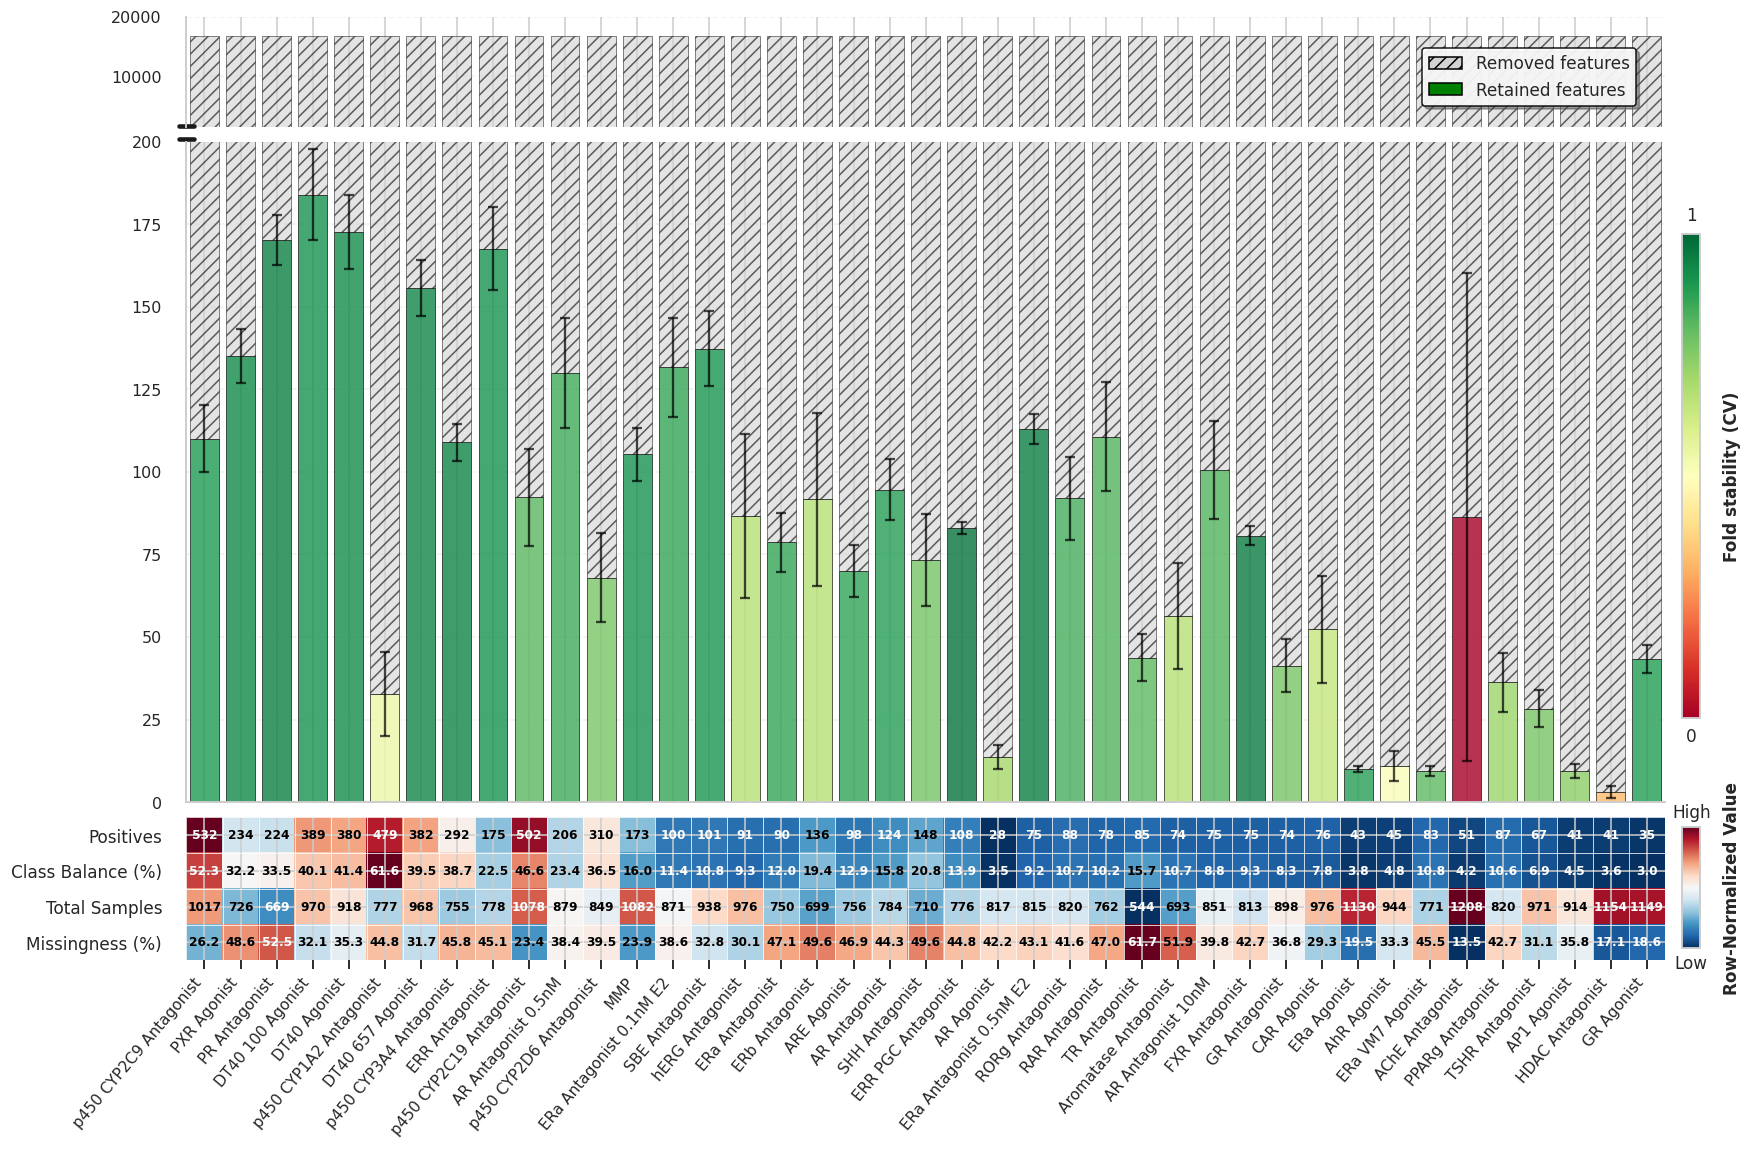

In [22]:
# FIGURE 1: Feature reduction and dataset characteristics across the 41 curated Tox21 assay endpoints. 
# Bar heights represent the number of transcriptomic features retained after Boruta selection relative 
# to the total feature space, and colors indicate cross-validation stability of retained features with 
# greener bars denoting more consistent feature selection across folds. Error bars represent the 
# standard deviation of feature counts across replicate Boruta runs. 
# The lower heatmap summarizes mean dataset characteristics for each assay across 3 folds, 
# including the number of positive samples, class balance, total sample size, and fraction of missing values. 
# Each metric was row-normalized to emphasize within-metric variation across assays. 
# Numerical annotations display the corresponding mean values.
# --------------------------------------------------------------------------------------- #


chemical_httr_assay_aggregated = pd.read_feather("../data/chemical_httr_assay_aggregated.feather")
assays   = [col for col in chemical_httr_assay_aggregated.columns if col.startswith("TOX21_")]
relevant = chemical_httr_assay_aggregated[assays + ['outcome_id']].drop_duplicates()

assay_missing_summary = (relevant[assays].isna().mean() * 100).rename_axis("assay_id").reset_index(name="missing_fraction")

def normalize_names(name):
    return (name.replace("0.1", "0_1")
                .replace("0.5", "0_5")
                .replace("1.0", "1_0"))

assay_missing_summary["assay_id_norm"] = assay_missing_summary["assay_id"].map(normalize_names)
performance_summary["assay_name_norm"] = performance_summary["assay_component_endpoint_name"].map(normalize_names)

def create_feature_reduction_waterfall(input_base_path=IN_BASE, out_base_path=FIGURES_AND_TABLES_OUT, heatmap_cmap='RdBu_r'):
    in_base = Path(input_base_path)
    out_base = Path(out_base_path)
    rows = []
    for d in (p for p in in_base.iterdir() if p.is_dir()):
        if d.name.endswith(suffixes_to_ignore):
            continue

        summary_fp = d / "run_summary.json"
        details_fp = d / "fold_details.csv"
        if not (summary_fp.exists() and details_fp.exists()):
            continue

        with open(summary_fp, "r") as f:
            initial = json.load(f).get("n_httr_features", 0)

        details_df = pd.read_csv(details_fp)
        
        fold_counts = []
        for idx, row in details_df.iterrows():
            if 'selected_httr_features' in row and pd.notna(row['selected_httr_features']):
                try:
                    features = json.loads(row['selected_httr_features'])
                    fold_counts.append(len(features))
                except (json.JSONDecodeError, TypeError):
                    continue
        
        if not fold_counts:
            continue
            
        fold_counts = pd.Series(fold_counts)
        mean, std = fold_counts.mean(), fold_counts.std()
        cv = (std / mean) if mean else 0

        rows.append({
            "endpoint": d.name,
            "initial_features": initial,
            "selected_features_mean": mean,
            "selected_features_std": std,
            "selected_features_min": fold_counts.min(),
            "selected_features_max": fold_counts.max(),
            "selected_features_cv": cv,
            "reduction_count_mean": initial - mean,
            "reduction_percentage_mean": (initial - mean) / initial * 100 if initial else 0,
            "fold_counts": fold_counts.tolist(),
        })

    if not rows:
        print("No feature reduction data found!")
        return

    df = pd.DataFrame(rows)
    df["display_name"] = df["endpoint"].map(names_map)
    perf_order = {f"TOX21_{idx.replace(' ', '_')}": i for i, idx in enumerate(performance_summary.index)}
    df["order"] = df["endpoint"].map(perf_order)
    df = df.sort_values("order").reset_index(drop=True)

    x = np.arange(len(df))
    cv_max = max(df["selected_features_cv"].max(), 1e-12)
    norm = Normalize(vmin=0, vmax=cv_max)
    cmap = plt.cm.RdYlGn
    colors = cmap(1 - df["selected_features_cv"] / cv_max)

    def plot_bars(ax):
        ax.bar(x, df["selected_features_mean"], color=colors, alpha=0.8, edgecolor="black", linewidth=0.5, width=0.8)
        ax.errorbar(x, df["selected_features_mean"], yerr=df["selected_features_std"],
                    fmt="none", ecolor="black", capsize=3, capthick=1.5, alpha=0.7)
        ax.bar(x, df["reduction_count_mean"], bottom=df["selected_features_mean"],
               color="lightgray", alpha=0.6, edgecolor="black", linewidth=0.5, hatch="///", width=0.8)
        ax.grid(True, axis="y", linestyle="--", alpha=0.3)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    missing_map_global = dict(zip(assay_missing_summary["assay_id_norm"], assay_missing_summary["missing_fraction"]))
    
    heatmap_vals = []
    for endpoint in df["endpoint"]:
        search_key = endpoint.replace("TOX21_", "").replace("_", " ")
        if search_key in performance_summary.index:
            row = performance_summary.loc[search_key]
            assay_norm_name = row.get('assay_name_norm')
            missing_val = missing_map_global.get(assay_norm_name, np.nan) if assay_norm_name else np.nan
            
            heatmap_vals.append({
                'Positives': row['test_pos_mean'],
                'Class Balance (%)': row['pos_fraction'] * 100,
                'Total Samples': row['total_samples'],
                'Missingness (%)': missing_val
            })
        else:
            heatmap_vals.append({'Positives': np.nan, 'Class Balance (%)': np.nan, 
                                'Total Samples': np.nan, 'Missingness (%)': np.nan})
    
    heatmap_data_df = pd.DataFrame(heatmap_vals).T
    
    def row_minmax(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng != 0 else pd.Series(0.5, index=s.index)
    
    norm_heatmap = heatmap_data_df.apply(row_minmax, axis=1)
    
    annot_heatmap = pd.DataFrame(index=heatmap_data_df.index, columns=heatmap_data_df.columns)
    for row in ['Positives', 'Total Samples']:
        annot_heatmap.loc[row] = heatmap_data_df.loc[row].round(0).map(
            lambda v: f"{int(v)}" if pd.notna(v) and v != 0 else ("0" if v == 0 else "N/A"))
    for row in ['Class Balance (%)', 'Missingness (%)']:
        annot_heatmap.loc[row] = heatmap_data_df.loc[row].map(lambda v: f"{v:.1f}" if pd.notna(v) else "N/A")
    
    fig = plt.figure(figsize=(16, 11))
    gs = fig.add_gridspec(3, 1, height_ratios=[1, 6, 1.3], hspace=0.05, left=0.08, right=0.92, bottom=0.20)
    
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1], sharex=ax_top)
    ax_heat = fig.add_subplot(gs[2], sharex=ax_top)
    
    for ax in (ax_top, ax_bot):
        plot_bars(ax)
    ax_top.set_ylim(1600, 20000)
    ax_bot.set_ylim(0, 200)

    d = .005
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=3)
    ax_top.plot((-d, +d), (+d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (0.999+d, 0.999+d), **kwargs)

    ax_bot.set_xticks(x)
    ax_bot.set_xticklabels([])
    ax_top.spines["bottom"].set_visible(False)
    ax_top.tick_params(bottom=False)
    
    cmap_heat = mpl.colormaps.get_cmap(heatmap_cmap)
    im = ax_heat.imshow(norm_heatmap.values, aspect='auto', cmap=heatmap_cmap, 
                        vmin=0, vmax=1, interpolation='nearest')
    
    for spine in ax_heat.spines.values():
        spine.set_visible(False)
    
    for i in range(norm_heatmap.shape[0]):
        for j in range(norm_heatmap.shape[1]):
            text = annot_heatmap.iloc[i, j]
            normalized_value = norm_heatmap.iloc[i, j]
            rgba = cmap_heat(normalized_value)
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "white" if luminance < 0.5 else "black"
            ax_heat.text(j, i, text, ha="center", va="center", 
                        color=text_color, fontsize=8, weight='bold')
    
    ax_heat.set_yticks(range(len(norm_heatmap.index)))
    ax_heat.set_yticklabels(norm_heatmap.index, rotation=0, fontsize=11)
    ax_heat.set_xticks(range(len(norm_heatmap.columns)))
    ax_heat.set_xticklabels(df["display_name"], rotation=45, ha="right", fontsize=10)
    
    for i in range(len(norm_heatmap.columns) + 1):
        ax_heat.axvline(i - 0.5, color='white', linewidth=0.5)
    for i in range(len(norm_heatmap.index) + 1):
        ax_heat.axhline(i - 0.5, color='white', linewidth=0.5)
    
    ax_heat.set_xlim(-0.5, len(norm_heatmap.columns) - 0.5)
    ax_heat.set_ylim(len(norm_heatmap.index) - 0.5, -0.5)
    ax_heat.set_ylabel('')
    ax_heat.set_xlabel('')
    
    ax_top.set_xticks([])
    ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax_bot.set_xticks([])
    ax_bot.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    for ax in (ax_top, ax_bot, ax_heat):
        ax.tick_params(axis="y", which="both", pad=10)

    legend_elements = [
        Patch(facecolor="lightgray", edgecolor="black", hatch="///", label="Removed features"),
        Patch(facecolor="green", edgecolor="black", label="Retained features")
    ]

    ax_top.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0.83, 0.79), 
                  fontsize=11, frameon=True, fancybox=True, shadow=True, framealpha=0.9,
                  edgecolor='black', facecolor='white')

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.93, 0.4, 0.01, 0.4])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Fold stability (CV)", fontsize=11, labelpad=15, fontweight='bold')
    cbar.set_ticks([])
    cbar.ax.text(0.5, 1.02, '1', ha='center', va='bottom', fontsize=11, transform=cbar.ax.transAxes)
    cbar.ax.text(0.5, -0.02, '0', ha='center', va='top', fontsize=11, transform=cbar.ax.transAxes)
    
    cbar_heat_ax = fig.add_axes([0.93, 0.21, 0.01, 0.10])
    cbar_heat = fig.colorbar(im, cax=cbar_heat_ax)
    cbar_heat.set_label("Row-Normalized Value", fontsize=11, labelpad=15, fontweight='bold')
    cbar_heat.set_ticks([])
    cbar_heat.ax.text(0.5, 1.05, 'High', ha='center', va='bottom', fontsize=11, transform=cbar_heat.ax.transAxes)
    cbar_heat.ax.text(0.5, -0.05, 'Low', ha='center', va='top', fontsize=11, transform=cbar_heat.ax.transAxes)

    fig.subplots_adjust(left=0.08, right=0.92, bottom=0.17, top=0.98)
    
    ax_heat.set_xticks(range(len(df)))
    ax_heat.set_xticklabels(df["display_name"], rotation=50, ha="right", fontsize=10)
    ax_heat.tick_params(axis='x', labelbottom=True, bottom=True)
    
    plt.savefig(out_base / "figure_01_feature_reduction_waterfall.png", bbox_inches="tight", dpi=300)
    #plt.savefig(out_base / "figure_01_feature_reduction_waterfall.svg", bbox_inches="tight")

    plt.show()
    return df


reduction_summary = create_feature_reduction_waterfall(input_base_path=IN_BASE, out_base_path=FIGURES_AND_TABLES_OUT, heatmap_cmap='RdBu_r')

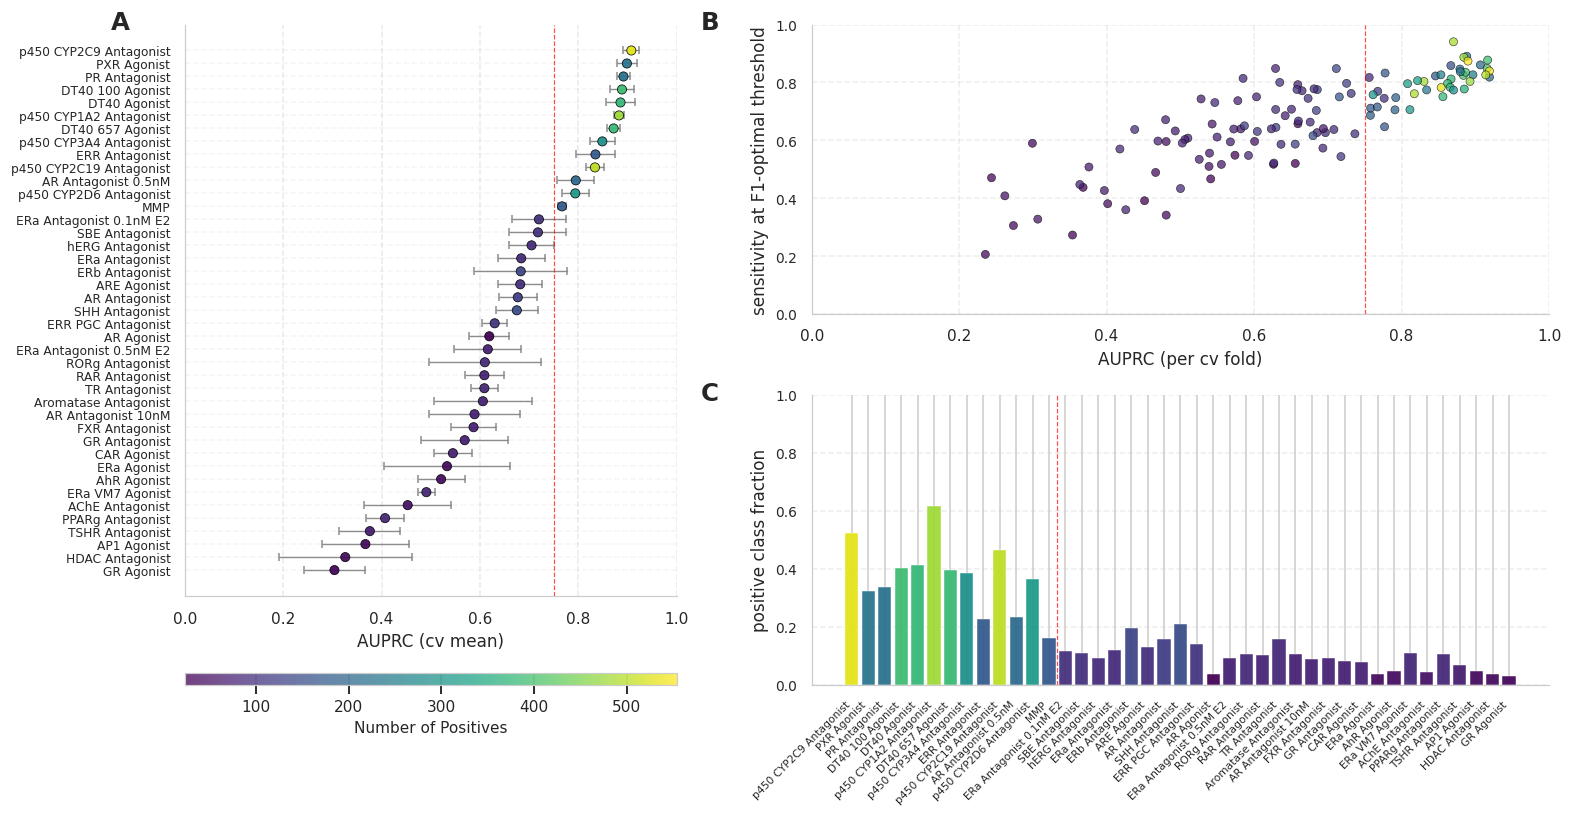

Out of 41 assays, 13 are considered predictable (mean PR AUC > 0.75):
- TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881
- TOX21_DT40_100_LUC
- TOX21_DT40_657_LUC
- TOX21_DT40_LUC
- TOX21_ERR_LUC_Antagonist
- TOX21_MMP_ratio
- TOX21_PR_BLA_Antagonist_ratio
- TOX21_PXR_LUC_Agonist
- TOX21_p450_CYP1A2_Antagonist
- TOX21_p450_CYP2C19_Antagonist
- TOX21_p450_CYP2C9_Antagonist
- TOX21_p450_CYP2D6_Antagonist
- TOX21_p450_CYP3A4_Antagonist

These assays will be retained for further analysis.


In [23]:
# FIGURE 2: Cross-validated model performance, sensitivity, and class balance across the 41 curated Tox21 assays. 
# (A) Each point shows the mean area under the precision–recall curve (AUPRC) for individual assays, 
# with horizontal error bars indicating the standard deviation across cross-validation folds. 
# Point colors reflect the mean number of positive samples in the test sets, illustrating variation in class balance across assays. 
# The vertical dashed red line (AUPRC = 0.75) denotes the empirical performance threshold used to identify well-performing models for downstream analyses. 
# (B) Relationship between fold-level AUPRC and sensitivity at the F₁-optimal decision threshold. 
# Each point represents a single cross-validation fold, colored by the number of positive samples in that fold. 
# The vertical dashed red line marks the same AUPRC = 0.75 reference threshold as in panel A, 
# enabling direct comparison of fold-level and assay-level performance. 
# (C) Fraction of positive samples per assay, colored according to the shared “number of positives” color scale. 
# The vertical dashed red line corresponds to the same AUPRC = 0.75 reference threshold, facilitating visual alignment across panels.
# --------------------------------------------------------------------------------------- #

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 11,
    "axes.titlesize": 11, "axes.labelsize": 11, "axes.linewidth": 0.8,
    "xtick.labelsize": 10, "ytick.labelsize": 9
})

fig = plt.figure(figsize=(16,10))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.5], height_ratios=[1, 1], hspace=0.28, wspace=0.22)

ax1 = fig.add_subplot(gs[:, 0])  
ax2 = fig.add_subplot(gs[0, 1])  
ax3 = fig.add_subplot(gs[1, 1])  

pos_min = min(all_fold_metrics["test_pos"].min(), performance_summary["test_pos_mean"].min())
pos_max = max(all_fold_metrics["test_pos"].max(), performance_summary["test_pos_mean"].max())
norm_pos = mpl.colors.Normalize(vmin=pos_min, vmax=pos_max)
cmap = mpl.colormaps.get_cmap("viridis")

# Panel A: Assay-level PR-AUC
ax1.errorbar(performance_summary["pr_auc_mean"], performance_summary.index,
    xerr=performance_summary["pr_auc_std"], fmt="none", ecolor="0.5", elinewidth=0.9,
    capsize=2.5, alpha=0.9, zorder=1)
ax1.scatter(performance_summary["pr_auc_mean"], performance_summary.index,
    c=performance_summary["test_pos_mean"], s=36, alpha=0.95, linewidths=0.5,
    edgecolors="black", cmap=cmap, norm=norm_pos, zorder=2)
ax1.invert_yaxis()
ax1.set_xlim(0,1)
ax1.set_yticks(range(len(performance_summary)))
ax1.set_yticklabels(performance_summary['display_name'], fontsize=8)
ax1.set_xlabel("AUPRC (cv mean)")
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax1.grid(axis="y", linestyle="--", alpha=0.20)
ax1.text(-0.15, 1.025, 'A', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top')
ax1.axvline(x=0.75, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

# Panel B: Fold-level AUPRC vs Sensitivity
sc2 = ax2.scatter(all_fold_metrics["pr_auc"], all_fold_metrics["recall_at_optimal"],
    c=all_fold_metrics["test_pos"], s=28, alpha=0.75, linewidths=0.4, edgecolors="black",
    cmap=cmap, norm=norm_pos)
ax2.set_xlabel("AUPRC (per cv fold)")
ax2.set_ylabel("sensitivity at F1-optimal threshold")
ax2.set_xlim(0,1)
ax2.set_ylim(0,1)
ax2.grid(True, linestyle="--", alpha=0.35)
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top')
ax2.axvline(x=0.75, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

# Panel C: Class imbalance (positive fractions)
x_positions = range(len(performance_summary))
ax3.bar(x_positions, performance_summary['pos_fraction'],
        color=cmap(norm_pos(performance_summary['test_pos_mean'].values)),
        linewidth=0.3, alpha=0.95)
ax3.set_xticks(x_positions)
ax3.set_xticklabels(performance_summary['display_name'], rotation=45, ha="right", fontsize=7)
ax3.set_ylabel("positive class fraction")
ax3.set_ylim(0, 1)
ax3.grid(axis="y", linestyle="--", alpha=0.35)
ax3.text(-0.15, 1.05, 'C', transform=ax3.transAxes, fontsize=16, fontweight='bold', va='top')
ax3.axvline(x=12.5, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

for ax in [ax1, ax2, ax3]:
    for spine in ("top","right"):
        ax.spines[spine].set_visible(False)

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax1)

cax = divider.append_axes("bottom", size="2%", pad=0.7)

cbar = fig.colorbar(sc2, cax=cax, orientation="horizontal")
cbar.set_label("Number of Positives", fontsize=10)
cbar.solids.set_rasterized(True)

fig.subplots_adjust(bottom=0.28)

fig.savefig(FIGURES_AND_TABLES_OUT / "figure_02_assay_performance_metrics_panel.png", bbox_inches="tight", dpi=600)
#fig.savefig(FIGURES_AND_TABLES_OUT / "figure_02_assay_performance_metrics_panel.svg", bbox_inches="tight")
plt.show()

# Assays with an average PR AUC > 0.75 are considered "predictable", and are retained for further analysis
all_assays = all_fold_metrics["assay"].unique()
assays = []
predictable_assays = all_fold_metrics.groupby("assay", observed=True).filter(lambda x: x["pr_auc"].mean() > 0.75)["assay"].unique()
print(f"Out of {len(all_assays)} assays, {len(predictable_assays)} are considered predictable (mean PR AUC > 0.75):")
for assay in predictable_assays:
    assays.append(assay)
    print(f"- {assay}")

print("\nThese assays will be retained for further analysis.")

In [24]:
# FIGURE 3: SHAP-based feature importance analysis for predictable assays.
# For each assay with AUPRC > 0.75, this analysis:
# 1. Ranks features by mean absolute SHAP value across all test samples
# 2. Generates violin plots showing SHAP value distributions for top 20 features
# --------------------------------------------------------------------------------------- #

OUT_BASE = Path("../output")
GENERATE_PLOTS = True
TOP_K = 20
SHAP_VIOLIN_OUT = FIGURES_AND_TABLES_OUT / "SHAP_violin_plots"

SHAP_VIOLIN_OUT.mkdir(parents=True, exist_ok=True)

def rank_features_for_assay(assay_dir):
    oof_path = assay_dir / "shap" / "oof_shap.feather"
    if not oof_path.exists():
        return None

    oof = pd.read_feather(oof_path)
    shap_cols = [c for c in oof.columns if c.startswith("SHAP_")]
    if not shap_cols:
        return None

    mean_abs = oof[shap_cols].abs().mean()

    has_labels = "y_true" in oof.columns
    if has_labels:
        pos_mask = (oof["y_true"] == 1)
        neg_mask = (oof["y_true"] == 0)
        mean_pos = oof.loc[pos_mask, shap_cols].mean()
        mean_neg = oof.loc[neg_mask, shap_cols].mean()
        
        shap_corr = {}
        y = oof["y_true"].astype(float).values
        for c in shap_cols:
            x = oof[c].values
            if np.std(x) == 0:
                shap_corr[c] = np.nan
            else:
                shap_corr[c] = np.corrcoef(x, y)[0, 1]
        shap_corr = pd.Series(shap_corr)
    else:
        mean_pos  = pd.Series(index=shap_cols, dtype=float)
        mean_neg  = pd.Series(index=shap_cols, dtype=float)
        shap_corr = pd.Series(index=shap_cols, dtype=float)

    features = [c.replace("SHAP_", "") for c in shap_cols]

    df = pd.DataFrame({
        "feature": features,
        "mean_abs_shap": mean_abs.values,
        "mean_shap_pos": mean_pos.reindex(shap_cols).values if has_labels else np.nan,
        "mean_shap_neg": mean_neg.reindex(shap_cols).values if has_labels else np.nan,
        "shap_corr_with_label": shap_corr.reindex(shap_cols).values if has_labels else np.nan,
    })
    
    df = df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    df["rank_by_abs_shap"] = np.arange(1, len(df) + 1)

    out_path = assay_dir / "feature_ranking.csv"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    return df

CUSTOM_CMAP = LinearSegmentedColormap.from_list(
    "colors",
    [(0.00, "#2c84fb"), (0.25, "#2c84fb"), (0.75, "#ff1651"), (1.00, "#ff1651")]
 )

def load_topk(feather_path, top_k):
    oof = pd.read_feather(feather_path)
    shap_cols = [c for c in oof.columns if c.startswith("SHAP_")]
    if not shap_cols: return [], None, None, None

    valid_shap_cols = [c for c in shap_cols if np.any(np.isfinite(oof[c].values))]
    mean_abs = oof[valid_shap_cols].abs().mean().sort_values(ascending=False)
    top_cols = mean_abs.index[:top_k]
    shap_mat = oof[top_cols].to_numpy()

    feature_names = [c.replace("SHAP_", "") for c in top_cols]
    have_all_values = all(b in oof.columns for b in feature_names)
    X_vals = oof[feature_names].to_numpy() if have_all_values else None

    return feature_names, shap_mat, X_vals, mean_abs.loc[top_cols]


def scale(x):
    x = x.astype(float)
    m = np.isfinite(x)
    out = np.full_like(x, np.nan, float)
    if not np.any(m): return out
    q1, q99 = np.nanpercentile(x[m], [1, 99])
    if q99 <= q1:
        out[m] = 0.5
        return out
    xc = np.clip(x, q1, q99)
    out[m] = (xc[m] - q1) / (q99 - q1)
    return out


def violin_plot(ax, shap_mat, feature_names, feature_values=None, bins=200):
    n_samples, n_features = shap_mat.shape
    y_positions = np.arange(n_features)[::-1]
    ax.axvline(0.0, linewidth=1, color="black", alpha=0.25, zorder=1)

    finite_vals = shap_mat[np.isfinite(shap_mat)]
    if finite_vals.size > 0:
        abs_max = np.max(np.abs(finite_vals))
        ax.set_xlim(-abs_max, abs_max)

    valid_positions, valid_names, valid_idx = [], [], []
    for j, pos in enumerate(y_positions):
        s = shap_mat[:, j]
        s = s[np.isfinite(s)]
        if s.size > 0:
            valid_idx.append(j)
            valid_positions.append(pos)
            valid_names.append(feature_names[j])

    if valid_positions:
        ax.set_ylim(min(valid_positions) - 0.6, max(valid_positions) + 0.6)

    ax.grid(True, axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
    ax.grid(True, axis='y', linestyle=':', linewidth=0.3, alpha=0.6)

    for j, pos in zip(valid_idx, valid_positions):
        svals = shap_mat[:, j]
        m = np.isfinite(svals)
        s = svals[m]
        if s.size == 0: continue

        f = None
        if feature_values is not None:
            fvals = feature_values[:, j]
            f = scale(fvals)[m]

        parts = ax.violinplot([s], positions=[pos], vert=False, widths=0.6,
                               showmeans=False, showmedians=False, showextrema=False)
        body = parts["bodies"][0]
        verts = body.get_paths()[0].vertices
        body.remove()

        patch = PathPatch(MplPath(verts), facecolor="none", edgecolor="black", linewidth=0.3, alpha=0.9, zorder=3)
        ax.add_patch(patch)

        x, y = verts[:, 0], verts[:, 1]
        xmin, xmax = np.min(x), np.max(x)
        ymin_v, ymax_v = np.min(y), np.max(y)
        if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax == xmin: continue

        edges = np.linspace(xmin, xmax, bins + 1)
        idx = np.digitize(s, edges) - 1
        idx = np.clip(idx, 0, bins - 1)
        col = np.full(bins, 0.5, dtype=float)
        if f is not None and f.size == s.size:
            for b in range(bins):
                mb = idx == b
                if np.any(mb): col[b] = np.nanmean(f[mb])

        img = col[np.newaxis, :]
        im = ax.imshow(img, extent=[xmin, xmax, ymin_v, ymax_v], cmap=CUSTOM_CMAP,
                       vmin=0.0, vmax=1.0, aspect="auto", origin="lower", interpolation="bilinear", zorder=2)
        im.set_clip_path(patch)

    ax.set_yticks(valid_positions)
    ax.set_yticklabels(valid_names, fontsize=10)
    ax.set_xlabel("SHAP value", fontsize=11)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)


def plot_violin_plus_importance(assay_dir, feature_names, shap_mat, feature_values, save=False):
    valid_feat_mask = ~np.all(~np.isfinite(shap_mat), axis=0)
    shap_mat_f = shap_mat[:, valid_feat_mask]
    feature_names_f = [f for f, keep in zip(feature_names, valid_feat_mask) if keep]
    feature_values_f = feature_values[:, valid_feat_mask] if feature_values is not None else None
    
    if shap_mat_f.size == 0: return

    mean_abs_now = np.nanmean(np.abs(shap_mat_f), axis=0)
    order = np.argsort(-mean_abs_now)
    shap_mat_ord = shap_mat_f[:, order]
    feature_names_ord = [feature_names_f[i] for i in order]
    importance_ord = mean_abs_now[order]
    feature_values_ord = feature_values_f[:, order] if feature_values_f is not None else None

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 9), dpi=160,
                                            gridspec_kw={"width_ratios": [4, 1], "wspace": 0.05})

    violin_plot(ax_left, shap_mat_ord, feature_names_ord, feature_values=feature_values_ord, bins=3)

    if feature_values_ord is not None:
        norm = Normalize(vmin=0.0, vmax=1.0)
        sm = ScalarMappable(norm=norm, cmap=CUSTOM_CMAP)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax_left, fraction=0.046, pad=0.04)
        cbar.set_ticks([]); cbar.outline.set_linewidth(10); cbar.outline.set_edgecolor("white")
        cbar.ax.text(0.5, 1.0, "High", ha="center", va="bottom", fontsize=9, transform=cbar.ax.transAxes)
        cbar.ax.text(0.5, 0.0, "Low", ha="center", va="top", fontsize=9, transform=cbar.ax.transAxes)
        cbar.set_label("Feature value", labelpad=-37.5, fontsize=10)

    assay_pretty = assay_dir.name.replace("_", " ").replace("TOX21", "")
    ax_left.set_title(f"Top {TOP_K} SHAP Plot — {assay_pretty}", fontsize=14, fontweight='bold', loc="center", pad=10)

    y_pos = np.arange(len(feature_names_ord))[::-1]
    bars = ax_right.barh(y_pos, importance_ord, alpha=0.9, height=0.6, color="#00B894")
    ax_right.set_yticks(y_pos); ax_right.set_yticklabels([]); ax_right.set_xlabel("mean(|SHAP|)", fontsize=10)
    ax_right.set_title("Feature Importance", fontsize=14, pad=10, fontweight="bold")
    ax_right.set_ylim(ax_left.get_ylim())

    max_val = np.nanmax(importance_ord)
    pad = (max_val * 0.02) if np.isfinite(max_val) and max_val > 0 else 0.01
    for bar, val in zip(bars, importance_ord):
        ax_right.text(val + pad, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8, alpha=0.85)

    if save: 
        out_path = SHAP_VIOLIN_OUT / f"shap_{assay_dir.name}.svg"
        out_path.parent.mkdir(parents=True, exist_ok=True)
        #plt.savefig(out_path, bbox_inches='tight', format="svg")
        plt.savefig(out_path.with_suffix('.png'), bbox_inches='tight', format="png", dpi=300)
        plt.close(fig)
    else: 
        plt.show()

predictable_assays_set = set(predictable_assays)
all_rows = []

for assay_dir in sorted([p for p in OUT_BASE.iterdir() if p.is_dir()]):
    if assay_dir.name in predictable_assays_set:
        df_rank = rank_features_for_assay(assay_dir)
        if df_rank is not None:
            df_rank["assay"] = assay_dir.name
            all_rows.append(df_rank)

        if GENERATE_PLOTS:
            shap_file = assay_dir / "shap" / "oof_shap.feather"
            if shap_file.exists():
                f_names, s_mat, x_v, _ = load_topk(shap_file, TOP_K)
                if s_mat is not None and s_mat.size > 0:
                    plot_violin_plus_importance(assay_dir, f_names, s_mat, x_v, save=True)

print(f"Done. Ranked {len(all_rows)} assays. Plots generated: {GENERATE_PLOTS}")

# extra 
assay_key = "TOX21_PR_BLA_Antagonist_ratio"
target_out_dir = Path("../output/figures_and_tables")
target_out_dir.mkdir(parents=True, exist_ok=True)

source_png = SHAP_VIOLIN_OUT / f"shap_{assay_key}.png"
source_svg = SHAP_VIOLIN_OUT / f"shap_{assay_key}.svg"

target_png = target_out_dir / "figure_03_SHAP_plot_PR_antagonist.png"
target_svg = target_out_dir / "figure_03_SHAP_plot_PR_antagonist.svg"

if source_png.exists():
    !cp {source_png} {target_png}

if source_svg.exists():
    !cp {source_svg} {target_svg}

Done. Ranked 13 assays. Plots generated: True


<br>

#### **02** - SUPPLEMENTARY INFORMATION

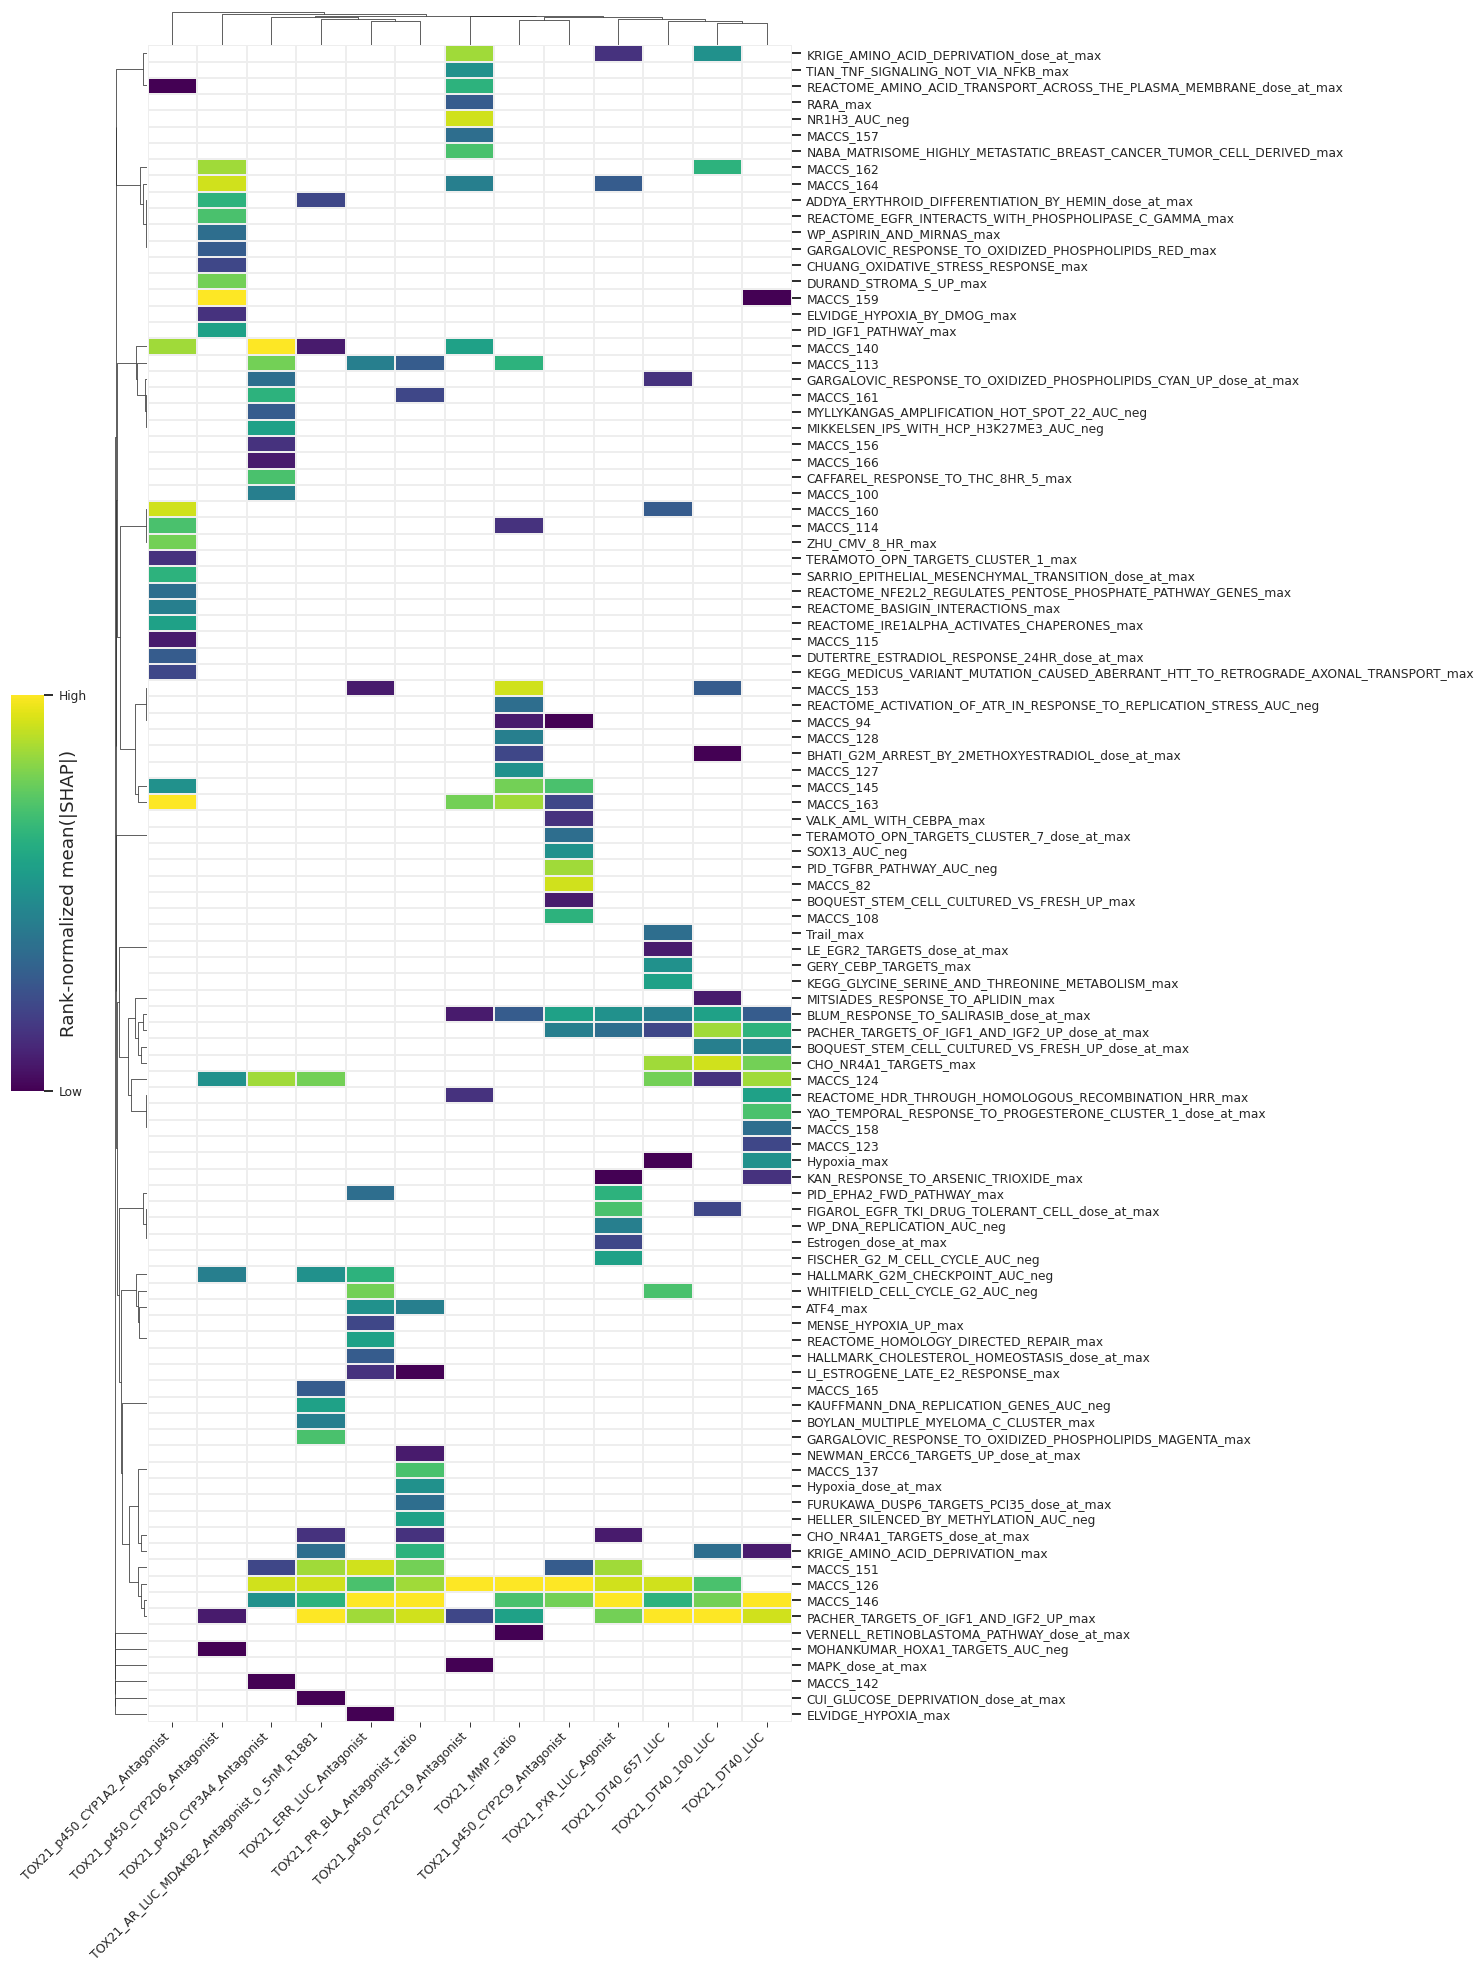

In [25]:
# SUPPLEMENTARY FIGURE 14: Cross-assay overlap of top SHAP features across predictive Tox21 endpoints.
# For assays with mean PR AUC > 0.75, the top 20 features are selected by mean absolute
# out-of-fold SHAP value and merged into a shared feature-by-assay matrix.
# Values are rank-normalized within each assay (1 = highest-ranked feature), with missing
# entries indicating features not present in an assay-specific top-20 list.
# Rows (features) and columns (assays) are hierarchically clustered to highlight
# cross-assay patterns of shared and assay-specific importance.
# --------------------------------------------------------------------------------------- #

OUT_BASE = Path("../output")
FIG_OUT = FIGURES_AND_TABLES_OUT
FIG_OUT.mkdir(parents=True, exist_ok=True)

TOP_K = 15
MIN_ASSAY_HITS = 1

def load_topk_mean_abs_shap(feather_path, top_k):
    oof = pd.read_feather(feather_path)
    shap_cols = [c for c in oof.columns if c.startswith("SHAP_")]

    if not shap_cols:
        return pd.Series(dtype=float)
    
    s = oof[shap_cols].abs().mean().sort_values(ascending=False).head(top_k)
    s.index = [c.replace("SHAP_", "") for c in s.index]

    return s

def rank_normalize_within_assay(s: pd.Series) -> pd.Series:
    s = s.dropna()

    if s.empty:
        return s.astype(float)
    
    if len(s) == 1:
        return pd.Series(1.0, index=s.index, dtype=float)
    
    ranks = s.rank(ascending=False, method="average")
    norm = 1.0 - (ranks - 1.0) / (len(s) - 1.0)

    return norm.astype(float)

def safe_linkage(data: np.ndarray, metric: str, method: str = "average"):
    if data.shape[0] < 2:
        return None
    
    d = pdist(data, metric=metric)
    if len(d) == 0:
        return None
    
    if np.isnan(d).any() or np.isinf(d).any():
        d = np.nan_to_num(d, nan=1.0, posinf=1.0, neginf=0.0)

    return linkage(d, method=method)

assay_topk_importance = {}
for assay in sorted(set(predictable_assays)):
    f = OUT_BASE / assay / "shap" / "oof_shap.feather"
    if f.exists():
        s = load_topk_mean_abs_shap(f, TOP_K)
        if not s.empty:
            assay_topk_importance[assay] = s

if not assay_topk_importance:
    print("No top-k SHAP data found for predictive assays.")
else:
    assays   = sorted(assay_topk_importance)
    features = sorted(set().union(*(s.index for s in assay_topk_importance.values())))
    raw_df   = pd.DataFrame(index=features, columns=assays, dtype=float)

    for assay, s in assay_topk_importance.items():
        raw_df.loc[s.index, assay] = s.values

    hits = raw_df.notna().sum(axis=1)
    raw_df = raw_df.loc[hits >= MIN_ASSAY_HITS].copy()

    if raw_df.empty:
        print(f"No features remain after filtering to MIN_ASSAY_HITS >= {MIN_ASSAY_HITS}.")
    else:
        norm_df = raw_df.copy()
        for assay in norm_df.columns:
            col = norm_df[assay].dropna()
            if not col.empty:
                norm_df.loc[col.index, assay] = rank_normalize_within_assay(col)

        row_data = norm_df.fillna(0.0).to_numpy()
        col_presence = norm_df.notna().astype(int).T.to_numpy()

        row_Z = safe_linkage(row_data, metric="cosine", method="average")
        col_Z = safe_linkage(col_presence, metric="jaccard", method="average")

        sns.set_theme(style="white")
        n_rows, n_cols = norm_df.shape

        g = sns.clustermap(
            norm_df,
            row_linkage=row_Z,
            col_linkage=col_Z,
            cmap="viridis",
            mask=norm_df.isna(),
            linewidths=0.1,
            linecolor="#eeeeee",
            figsize=(15, 20),
            cbar_pos=(-0.05, 0.5, 0.02, 0.18), # x, y, width, height
            cbar_kws={"label": "Rank-normalized mean(|SHAP|)"},
            dendrogram_ratio=(0.05, 0.02),
        )

        row_order = (
            [norm_df.index[i] for i in g.dendrogram_row.reordered_ind]
            if g.dendrogram_row is not None
            else list(norm_df.index)
        )

        col_order = (
            [norm_df.columns[i] for i in g.dendrogram_col.reordered_ind]
            if g.dendrogram_col is not None
            else list(norm_df.columns)
        )

        y_ticks = np.arange(len(row_order)) + 0.5
        x_ticks = np.arange(len(col_order)) + 0.5

        g.ax_heatmap.set_yticks(y_ticks)
        g.ax_heatmap.set_yticklabels(row_order, fontsize=8)

        g.ax_heatmap.set_xticks(x_ticks)
        g.ax_heatmap.set_xticklabels(col_order, rotation=45, ha="right", fontsize=8)
        g.ax_heatmap.tick_params(axis="x", which="major", bottom=True, top=False, labelbottom=True, length=3, width=0.6, pad=2)

        cbar = g.ax_heatmap.collections[0].colorbar
        if cbar is not None:
            cbar.set_ticks([0.0, 1.0])
            cbar.set_ticklabels(["Low", "High"])
            cbar.ax.tick_params(labelsize=8)
            cbar.ax.yaxis.set_label_coords(1.5, 0.5)


        norm_df_clustered = norm_df.loc[row_order, col_order]
        raw_df_clustered = raw_df.loc[row_order, col_order]

        g.fig.savefig(FIG_OUT / "supplementary_figure_14_SHAP_heatmap.png", dpi=600, bbox_inches="tight")
        #g.fig.savefig(FIG_OUT / "supplementary_figure_14_SHAP_heatmap.svg", bbox_inches="tight")

        plt.show()

Rows in ablation long table: 369
Missing samples: 0 | Missing positives: 0 | Missing negatives: 0


,assay,baseline__pr_auc_mean,double_cell_httr_structure_MCF7_HepRG__pr_auc_mean,double_cell_httr_structure_MCF7_U2OS__pr_auc_mean,double_cell_httr_structure_U2OS_HepRG__pr_auc_mean,httr_only__pr_auc_mean,single_cell_httr_structure_HepRG__pr_auc_mean,single_cell_httr_structure_MCF7__pr_auc_mean,single_cell_httr_structure_U2OS__pr_auc_mean,structure_only__pr_auc_mean,...,structure_only__n_negatives_used,baseline__pos_fraction_used,double_cell_httr_structure_MCF7_HepRG__pos_fraction_used,double_cell_httr_structure_MCF7_U2OS__pos_fraction_used,double_cell_httr_structure_U2OS_HepRG__pos_fraction_used,httr_only__pos_fraction_used,single_cell_httr_structure_HepRG__pos_fraction_used,single_cell_httr_structure_MCF7__pos_fraction_used,single_cell_httr_structure_U2OS__pos_fraction_used,structure_only__pos_fraction_used
0,TOX21_AChE_Colorimetric_Antagonist,0.453343,0.493302,0.459835,0.499314,0.070840,0.460357,0.371171,0.301548,0.473334,...,3472,0.042207,0.042412,0.042802,0.041232,0.042207,0.040758,0.043564,0.041706,0.042207
1,TOX21_AP1_BLA_Agonist_ratio,0.367006,0.313992,0.180916,0.205770,0.116535,0.064165,0.260458,0.169643,0.288581,...,2617,0.045239,0.046090,0.045596,0.043800,0.045239,0.044390,0.047321,0.043210,0.045239
2,TOX21_ARE_BLA_Agonist_ratio,0.682454,0.635220,0.693825,0.600275,0.569758,0.536710,0.720463,0.654000,0.407147,...,1976,0.129132,0.133416,0.133333,0.118886,0.129132,0.118976,0.143617,0.118797,0.129132
3,TOX21_AR_BLA_Agonist_ratio,0.618739,0.495245,0.587770,0.490892,0.242200,0.602492,0.515595,0.646979,0.588446,...,2365,0.034694,0.035942,0.035942,0.031724,0.034694,0.031724,0.039000,0.031724,0.034694
4,TOX21_AR_BLA_Antagonist_ratio,0.676907,0.651721,0.724661,0.682066,0.652319,0.557983,0.690945,0.623647,0.508020,...,1981,0.157738,0.161329,0.161232,0.149318,0.157738,0.149425,0.169969,0.149211,0.157738
5,TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881,0.794632,0.795305,0.800537,0.789717,0.758269,0.765831,0.813424,0.764846,0.652732,...,2019,0.234067,0.238121,0.237992,0.224633,0.234067,0.224777,0.247895,0.224490,0.234067
6,TOX21_AR_LUC_MDAKB2_Antagonist_10nM_R1881,0.589294,0.593467,0.584061,0.609388,0.545412,0.507173,0.623468,0.628198,0.367672,...,2327,0.088166,0.089900,0.089850,0.084056,0.088166,0.084112,0.094017,0.084000,0.088166
7,TOX21_AhR_LUC_Agonist,0.521079,0.471751,0.512231,0.339230,0.254297,0.504973,0.519447,0.251772,0.463770,...,2698,0.047653,0.047691,0.047691,0.047562,0.047653,0.047562,0.047785,0.047562,0.047653
8,TOX21_Aromatase_LUC_Antagonist,0.606387,0.593996,0.582227,0.525114,0.517674,0.461180,0.672329,0.596730,0.476349,...,1858,0.106731,0.107143,0.107069,0.105854,0.106731,0.105939,0.108043,0.105769,0.106731
9,TOX21_CAR_LUC_Agonist,0.544910,0.540113,0.557939,0.536110,0.416108,0.461370,0.553152,0.512982,0.415050,...,2700,0.077869,0.079903,0.079903,0.073001,0.077869,0.073001,0.084859,0.073001,0.077869


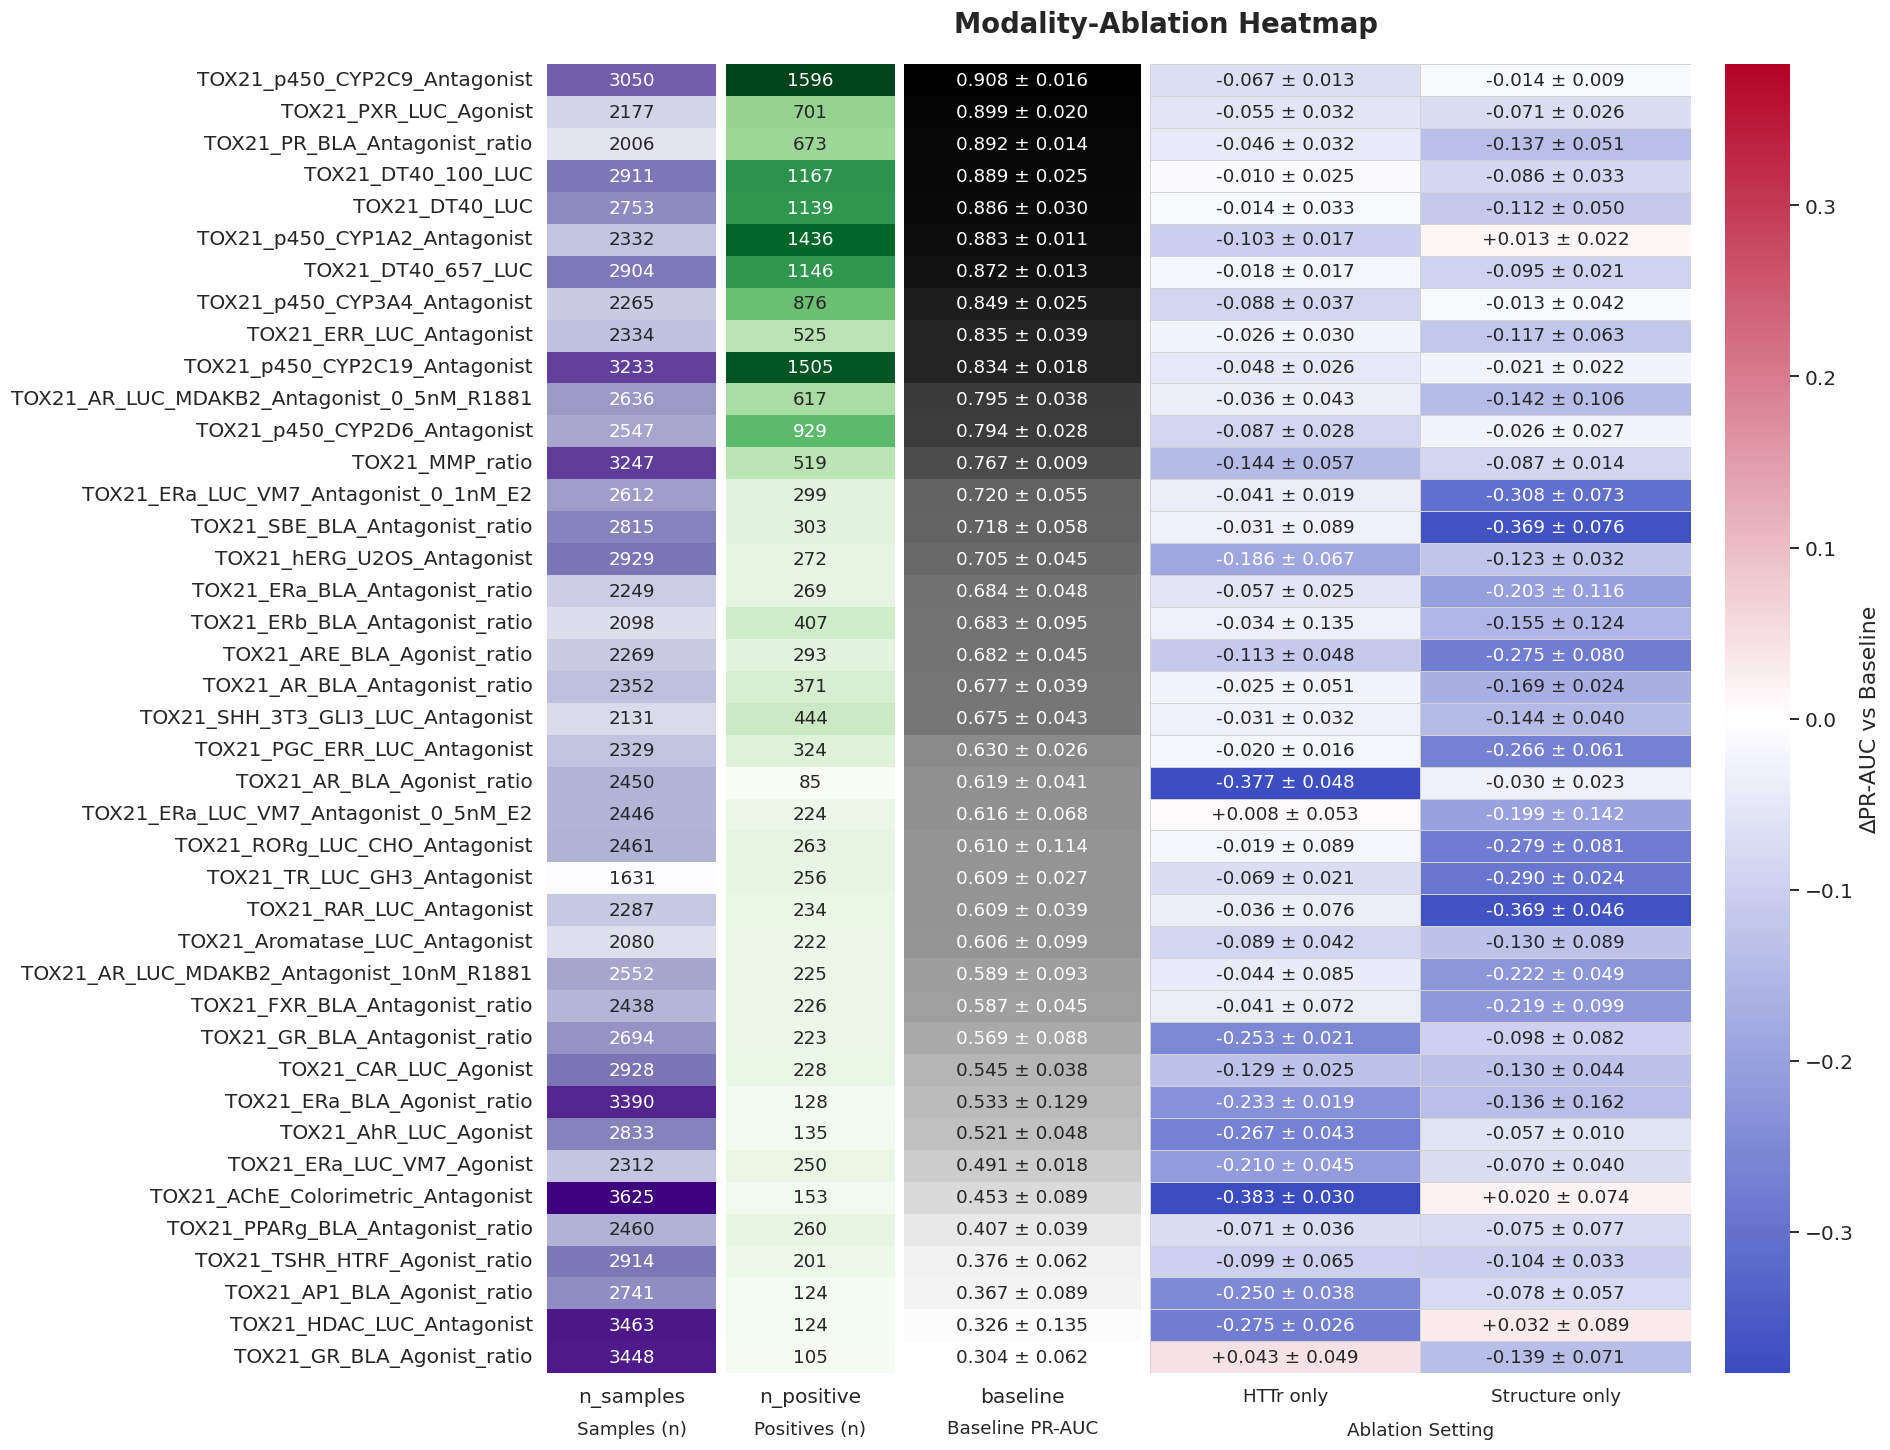

In [26]:
# SUPPLEMENTARY FIGURE 15: Modality ablation impact on predictive performance.
# For each assay and ablation setting, this analysis:
# 1. Aggregates fold-level PR-AUC statistics
# 2. Computes delta PR-AUC against baseline
# 3. Visualizes baseline and ablation deltas as an annotated heatmap panel
# --------------------------------------------------------------------------------------- #

OUT_BASE = Path("../output")
FIGURES_AND_TABLES_OUT = Path("../output/figures_and_tables")
FIGURES_AND_TABLES_OUT.mkdir(parents=True, exist_ok=True)


def read_ablation_fold_details(run_dir):
    details_fp = run_dir / "fold_details.csv"
    if not details_fp.exists():
        return None

    df = pd.read_csv(details_fp)
    if "pr_auc" not in df.columns:
        return None

    return df


def read_ablation_sample_usage(run_dir, details_df):
    n_samples_used = np.nan
    n_positives_used = np.nan
    n_negatives_used = np.nan

    run_summary_fp = run_dir / "run_summary.json"
    if run_summary_fp.exists():
        try:
            with open(run_summary_fp, "r") as f:
                run_summary = json.load(f)

            if pd.notna(run_summary.get("samples_with_target")):
                n_samples_used = int(run_summary["samples_with_target"])
            if pd.notna(run_summary.get("target_positives")):
                n_positives_used = int(run_summary["target_positives"])
            if pd.notna(run_summary.get("target_negatives")):
                n_negatives_used = int(run_summary["target_negatives"])
        except (OSError, json.JSONDecodeError, ValueError, TypeError):
            pass

    if pd.isna(n_samples_used) and "n_test" in details_df.columns:
        n_samples_used = int(details_df["n_test"].sum())
    if pd.isna(n_positives_used) and "test_pos" in details_df.columns:
        n_positives_used = int(details_df["test_pos"].sum())
    if pd.isna(n_negatives_used) and "test_neg" in details_df.columns:
        n_negatives_used = int(details_df["test_neg"].sum())

    if pd.isna(n_samples_used) and pd.notna(n_positives_used) and pd.notna(n_negatives_used):
        n_samples_used = int(n_positives_used + n_negatives_used)

    pos_fraction_used = np.nan
    if pd.notna(n_samples_used) and n_samples_used > 0 and pd.notna(n_positives_used):
        pos_fraction_used = float(n_positives_used / n_samples_used)

    return n_samples_used, n_positives_used, n_negatives_used, pos_fraction_used


def parse_run_name(run_name):
    parts = run_name.split("__")
    assay = parts[0]
    ablation = "baseline"
    cell_type = None

    if len(parts) > 1:
        ablation = parts[1]
        if ablation.startswith("single_cell_httr_structure") and len(parts) > 2:
            cell_type = parts[2]

    return assay, ablation, cell_type


rows = []
ablation_base = Path("../extra/ablation")
base_dirs = [p for p in OUT_BASE.iterdir() if p.is_dir()]
if ablation_base.exists():
    base_dirs.extend([p for p in ablation_base.iterdir() if p.is_dir()])
for run_dir in sorted(base_dirs):
    details_df = read_ablation_fold_details(run_dir)
    if details_df is None or details_df.empty:
        continue

    assay, ablation, cell_type = parse_run_name(run_dir.name)
    n_samples_used, n_positives_used, n_negatives_used, pos_fraction_used = read_ablation_sample_usage(run_dir, details_df)

    rows.append({
        "assay": assay,
        "ablation": ablation,
        "cell_type": cell_type,
        "pr_auc_mean": details_df["pr_auc"].mean(),
        "pr_auc_std": details_df["pr_auc"].std(),
        "n_samples_used": n_samples_used,
        "n_positives_used": n_positives_used,
        "n_negatives_used": n_negatives_used,
        "pos_fraction_used": pos_fraction_used,
    })

summary_df = pd.DataFrame(rows)
if summary_df.empty:
    print("No ablation fold_details.csv files found.")
else:
    summary_df["ablation_label"] = summary_df.apply(
        lambda r: f"{r['ablation']}_{r['cell_type']}" if pd.notna(r["cell_type"]) else r["ablation"],
        axis=1,
    )

    baseline_map = (
        summary_df.loc[summary_df["ablation_label"] == "baseline", ["assay", "pr_auc_mean"]]
        .set_index("assay")["pr_auc_mean"]
    )
    summary_df["baseline_pr_auc_mean"] = summary_df["assay"].map(baseline_map)
    summary_df["pr_auc_delta_vs_baseline"] = summary_df["pr_auc_mean"] - summary_df["baseline_pr_auc_mean"]

    summary_wide = summary_df.pivot_table(
        index="assay",
        columns="ablation_label",
        values="pr_auc_mean",
        aggfunc="first",
    ).reset_index()

    summary_std = summary_df.pivot_table(
        index="assay",
        columns="ablation_label",
        values="pr_auc_std",
        aggfunc="first",
    ).reset_index()

    metrics_for_master = [
        "pr_auc_mean",
        "pr_auc_std",
        "pr_auc_delta_vs_baseline",
        "n_samples_used",
        "n_positives_used",
        "n_negatives_used",
        "pos_fraction_used",
    ]

    master_parts = []
    for metric in metrics_for_master:
        part = summary_df.pivot_table(
            index="assay",
            columns="ablation_label",
            values=metric,
            aggfunc="first",
        )
        part.columns = [f"{col}__{metric}" for col in part.columns]
        master_parts.append(part)

    ablation_master_table = pd.concat(master_parts, axis=1).reset_index()

    missing_samples = summary_df["n_samples_used"].isna().sum()
    missing_pos = summary_df["n_positives_used"].isna().sum()
    missing_neg = summary_df["n_negatives_used"].isna().sum()

    print(f"Rows in ablation long table: {len(summary_df)}")
    print(f"Missing samples: {missing_samples} | Missing positives: {missing_pos} | Missing negatives: {missing_neg}")

display(ablation_master_table)


sns.set(style="whitegrid", font_scale=1.2)

master_df = ablation_master_table.copy()

mean_cols = [c for c in master_df.columns if c.endswith("__pr_auc_mean")]
std_cols = [c for c in master_df.columns if c.endswith("__pr_auc_std")]


# ---------------- table preparation ---------------- #
mean_df = master_df[["assay"] + mean_cols].copy()
mean_df = mean_df.rename(columns={c: c.replace("__pr_auc_mean", "") for c in mean_cols})

std_df = master_df[["assay"] + std_cols].copy()
std_df = std_df.rename(columns={c: c.replace("__pr_auc_std", "") for c in std_cols})

if "baseline" not in mean_df.columns:
    raise ValueError("Baseline column missing from ablation summary")

heatmap_data = mean_df.set_index("assay").sort_values("baseline", ascending=False)
std_data = std_df.set_index("assay").reindex(heatmap_data.index)

ablation_cols = [
    c
    for c in heatmap_data.columns
    if c != "baseline"
    and not c.startswith("single_cell_httr_structure")
    and not c.startswith("double_cell_httr_structure")
]
if not ablation_cols:
    raise ValueError("No non-single/non-double ablation columns left after filtering")

baseline = heatmap_data[["baseline"]].apply(pd.to_numeric, errors="coerce")
baseline_std = (
    std_data[["baseline"]].apply(pd.to_numeric, errors="coerce")
    if "baseline" in std_data.columns
    else pd.DataFrame(index=heatmap_data.index, columns=["baseline"])
)

delta_raw = heatmap_data[ablation_cols].subtract(heatmap_data["baseline"], axis=0)
delta_raw = delta_raw.apply(pd.to_numeric, errors="coerce")
delta_sd = std_data[ablation_cols].apply(pd.to_numeric, errors="coerce")

delta_raw.columns = delta_raw.columns.str.replace("_HepRG", "_HepaRG", regex=False)
delta_sd.columns = delta_raw.columns


# ---------------- color setup ---------------- #
vmax = np.nanmax(np.abs(delta_raw.values))
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1e-6

base_cmap = plt.colormaps["coolwarm"]
coolwarm_white_center = LinearSegmentedColormap.from_list(
    "coolwarm_white_center",
    [base_cmap(0.0), (1.0, 1.0, 1.0, 1.0), base_cmap(1.0)],
    N=256,
)

baseline_plot = baseline.fillna(0.0)
delta_plot = delta_raw.fillna(0.0)


# ---------------- metadata side columns ---------------- #
master_by_assay = master_df.set_index("assay")

if "baseline__n_samples_used" in master_df.columns:
    sample_series = heatmap_data.index.to_series().map(master_by_assay["baseline__n_samples_used"]).astype(float)
else:
    sample_series = pd.Series(index=heatmap_data.index, dtype=float)
    print("Warning: baseline__n_samples_used not found. Sample annotations will be empty.")

if "baseline__n_positives_used" in master_df.columns:
    positive_series = heatmap_data.index.to_series().map(master_by_assay["baseline__n_positives_used"]).astype(float)
else:
    positive_series = pd.Series(index=heatmap_data.index, dtype=float)
    print("Warning: baseline__n_positives_used not found. Positive annotations will be empty.")

sample_display = sample_series.fillna(0).astype(int).to_frame(name="n_samples")
positive_display = positive_series.fillna(0).astype(int).to_frame(name="n_positive")


# ---------------- annotation strings ---------------- #
baseline_annot = np.empty_like(baseline_plot.values, dtype=object)
for i in range(baseline_plot.shape[0]):
    mean_val = baseline.iloc[i, 0]
    std_val = baseline_std.iloc[i, 0] if baseline_std.shape[1] > 0 else np.nan
    if pd.notna(mean_val):
        baseline_annot[i, 0] = f"{mean_val:.3f} ± {std_val:.3f}" if pd.notna(std_val) else f"{mean_val:.3f}"
    else:
        baseline_annot[i, 0] = "NA"

delta_annot = np.empty_like(delta_plot.values, dtype=object)
for i in range(delta_plot.shape[0]):
    for j in range(delta_plot.shape[1]):
        delta_val = delta_raw.iloc[i, j]
        std_val = delta_sd.iloc[i, j] if j < delta_sd.shape[1] else np.nan
        if pd.notna(delta_val):
            delta_annot[i, j] = f"{delta_val:+.3f} ± {std_val:.3f}" if pd.notna(std_val) else f"{delta_val:+.3f}"
        else:
            delta_annot[i, j] = "NA"


# ---------------- plotting ---------------- #
fig = plt.figure(figsize=(15, 14))
gs = fig.add_gridspec(1, 4, width_ratios=[0.5, 0.5, 0.7, 2], wspace=0.03)

ax_samples = fig.add_subplot(gs[0])
sns.heatmap(
    sample_display,
    annot=True,
    fmt="d",
    cmap="Purples",
    cbar=False,
    annot_kws={"size": 12},
    ax=ax_samples,
)
ax_samples.set_xlabel("Samples (n)", fontsize=12, labelpad=8)
ax_samples.set_ylabel("")
ax_samples.set_yticklabels(ax_samples.get_yticklabels(), rotation=0)

ax_pos = fig.add_subplot(gs[1])
sns.heatmap(
    positive_display,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    annot_kws={"size": 12},
    ax=ax_pos,
)
ax_pos.set_xlabel("Positives (n)", fontsize=12, labelpad=8)
ax_pos.set_ylabel("")
ax_pos.set_yticklabels([])

ax_baseline = fig.add_subplot(gs[2])
sns.heatmap(
    baseline_plot,
    annot=baseline_annot,
    fmt="",
    cmap="Greys",
    cbar=False,
    annot_kws={"size": 12},
    ax=ax_baseline,
)
ax_baseline.set_xlabel("Baseline PR-AUC", fontsize=12, labelpad=8)
ax_baseline.set_ylabel("")
ax_baseline.set_yticklabels([])

ax_delta = fig.add_subplot(gs[3])
sns.heatmap(
    delta_plot,
    annot=delta_annot,
    fmt="",
    cmap=coolwarm_white_center,
    center=0,
    vmin=-vmax,
    vmax=vmax,
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "∆PR-AUC vs Baseline"},
    annot_kws={"size": 12},
    ax=ax_delta,
)
ax_delta.set_xticklabels(["HTTr only", "Structure only"], rotation=0, ha="center", fontsize=12)
ax_delta.set_xlabel("Ablation Setting", fontsize=12, labelpad=10)
ax_delta.set_yticklabels([])
ax_delta.set_ylabel("")

fig.suptitle("Modality-Ablation Heatmap", fontsize=18, fontweight="bold", y=0.995)
fig.subplots_adjust(top=0.96)


# ---------------- export ---------------- #
plt.savefig(
    FIGURES_AND_TABLES_OUT / "supplementary_figure_15_modality_ablation_vs_baseline_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

# plt.savefig(
#     FIGURES_AND_TABLES_OUT / "supplementary_figure_15_modality_ablation_vs_baseline_heatmap.svg",
#     bbox_inches="tight",
# )

plt.show()

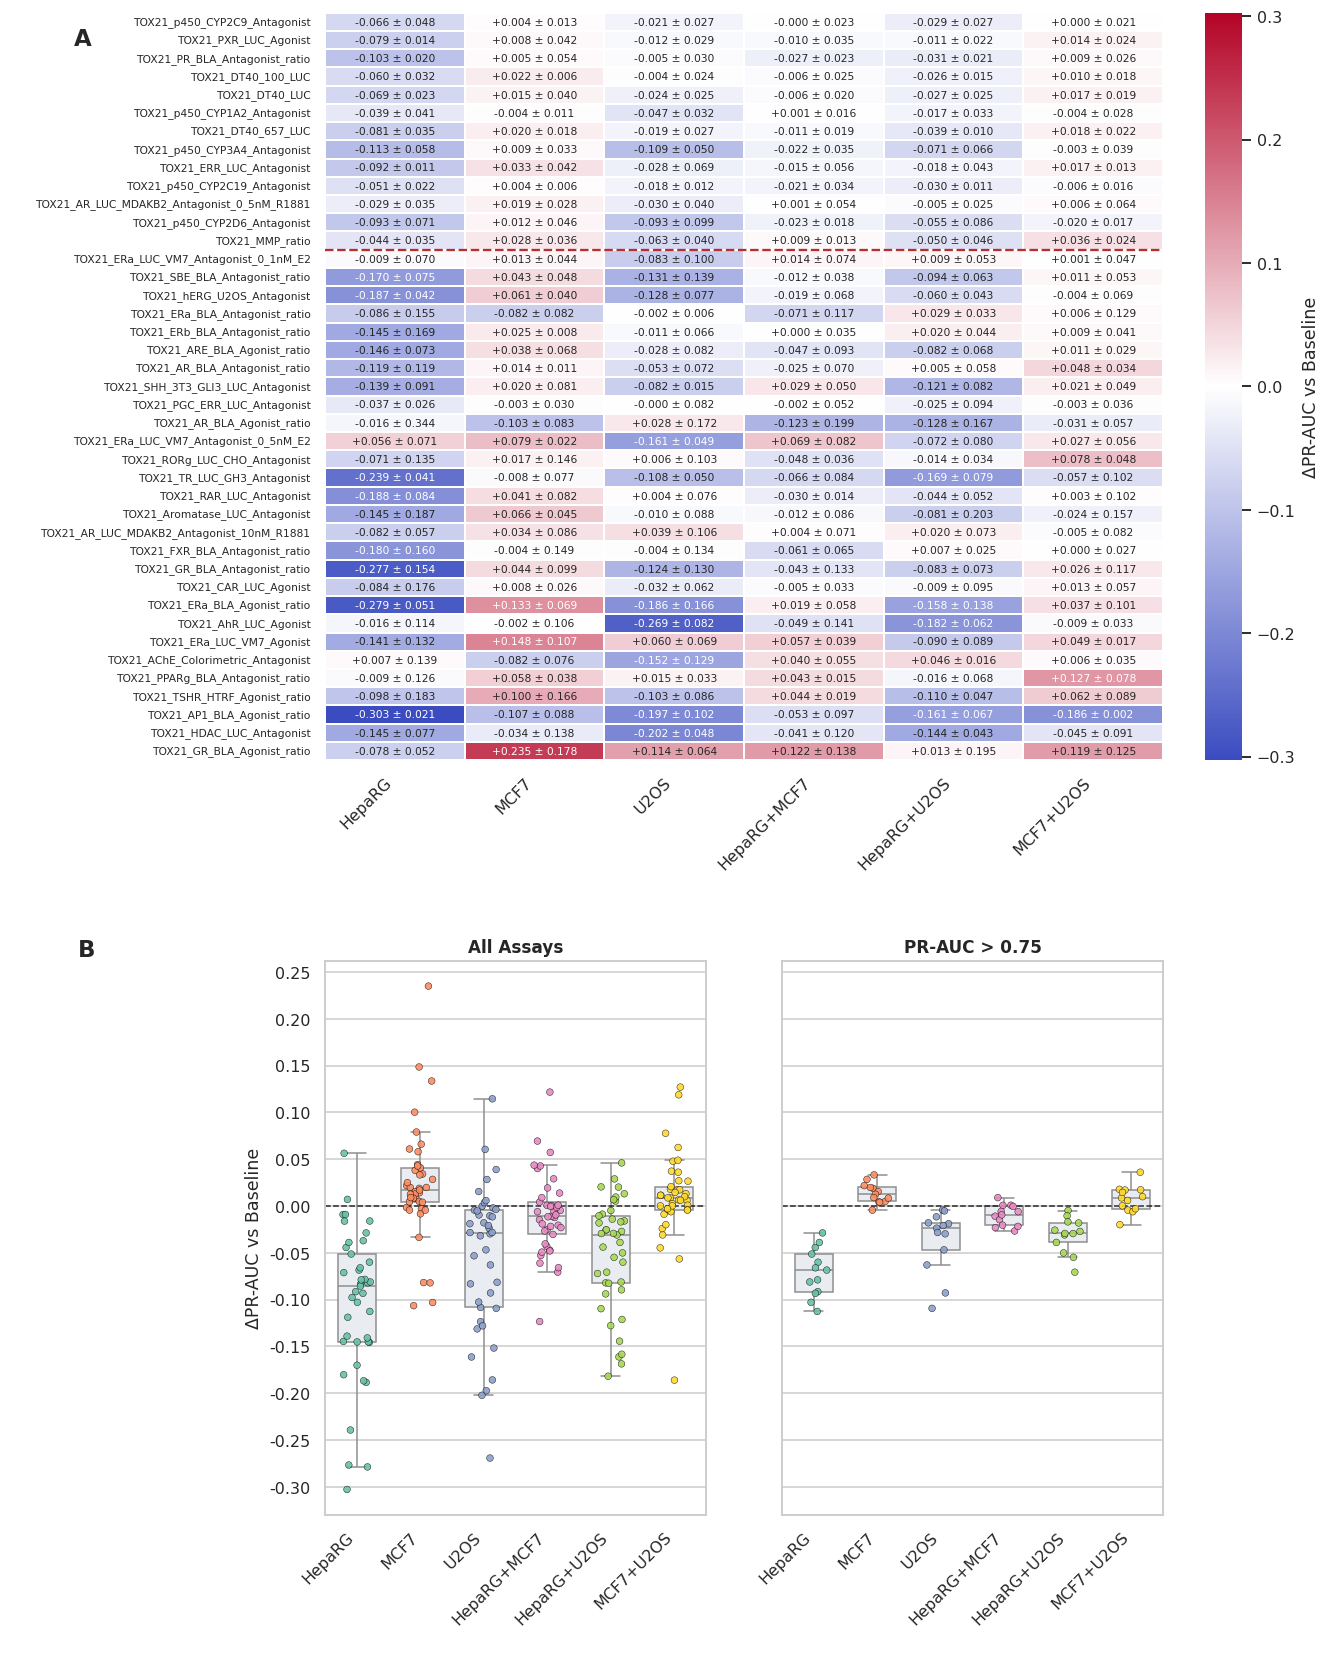

In [27]:
# SUPPLEMENTARY FIGURE 16: Cell-type ablation summary across assays.
# This combined figure includes:
# 1. Assay-level heatmap of delta PR-AUC vs baseline for single/double cell-type settings
# 2. Distribution summaries across all assays and high-performing assays (PR-AUC > 0.75)
# --------------------------------------------------------------------------------------- #

import matplotlib.ticker as mticker

# Rebuild summary_df on demand so this cell is standalone.
if "summary_df" not in globals() or summary_df is None or summary_df.empty:
    OUT_BASE = Path("../output")

    def read_ablation_fold_details(run_dir: Path):
        details_fp = run_dir / "fold_details.csv"
        if not details_fp.exists():
            return None
        df = pd.read_csv(details_fp)
        if "pr_auc" not in df.columns:
            return None
        return df

    def read_ablation_sample_usage(run_dir: Path, details_df: pd.DataFrame):
        n_samples_used = np.nan
        n_positives_used = np.nan
        n_negatives_used = np.nan

        run_summary_fp = run_dir / "run_summary.json"
        if run_summary_fp.exists():
            try:
                with open(run_summary_fp, "r") as f:
                    run_summary = json.load(f)
                if pd.notna(run_summary.get("samples_with_target")):
                    n_samples_used = int(run_summary["samples_with_target"])
                if pd.notna(run_summary.get("target_positives")):
                    n_positives_used = int(run_summary["target_positives"])
                if pd.notna(run_summary.get("target_negatives")):
                    n_negatives_used = int(run_summary["target_negatives"])
            except (OSError, json.JSONDecodeError, ValueError, TypeError):
                pass

        if pd.isna(n_samples_used) and "n_test" in details_df.columns:
            n_samples_used = int(details_df["n_test"].sum())
        if pd.isna(n_positives_used) and "test_pos" in details_df.columns:
            n_positives_used = int(details_df["test_pos"].sum())
        if pd.isna(n_negatives_used) and "test_neg" in details_df.columns:
            n_negatives_used = int(details_df["test_neg"].sum())
        if pd.isna(n_samples_used) and pd.notna(n_positives_used) and pd.notna(n_negatives_used):
            n_samples_used = int(n_positives_used + n_negatives_used)

        pos_fraction_used = np.nan
        if pd.notna(n_samples_used) and n_samples_used > 0 and pd.notna(n_positives_used):
            pos_fraction_used = float(n_positives_used / n_samples_used)

        return n_samples_used, n_positives_used, n_negatives_used, pos_fraction_used

    def parse_run_name(run_name: str):
        parts = run_name.split("__")
        assay = parts[0]
        ablation = "baseline"
        cell_type = None
        if len(parts) > 1:
            ablation = parts[1]
            if ablation.startswith("single_cell_httr_structure") and len(parts) > 2:
                cell_type = parts[2]
        return assay, ablation, cell_type

    rows = []
    ablation_base = Path("../extra/ablation")
    base_dirs = [p for p in OUT_BASE.iterdir() if p.is_dir()]
    if ablation_base.exists():
        base_dirs.extend([p for p in ablation_base.iterdir() if p.is_dir()])
    for run_dir in sorted(base_dirs):
        details_df = read_ablation_fold_details(run_dir)
        if details_df is None or details_df.empty:
            continue

        assay, ablation, cell_type = parse_run_name(run_dir.name)
        n_samples_used, n_positives_used, n_negatives_used, pos_fraction_used = read_ablation_sample_usage(run_dir, details_df)

        rows.append(
            {
                "assay": assay,
                "ablation": ablation,
                "cell_type": cell_type,
                "pr_auc_mean": details_df["pr_auc"].mean(),
                "pr_auc_std": details_df["pr_auc"].std(),
                "n_samples_used": n_samples_used,
                "n_positives_used": n_positives_used,
                "n_negatives_used": n_negatives_used,
                "pos_fraction_used": pos_fraction_used,
            }
        )

    summary_df = pd.DataFrame(rows)
    if summary_df.empty:
        raise ValueError("No ablation fold_details.csv files found in ../output")

    summary_df["ablation_label"] = summary_df.apply(
        lambda r: f"{r['ablation']}_{r['cell_type']}" if pd.notna(r["cell_type"]) else r["ablation"],
        axis=1,
    )
    baseline_map = (
        summary_df.loc[summary_df["ablation_label"] == "baseline", ["assay", "pr_auc_mean"]]
        .set_index("assay")["pr_auc_mean"]
    )
    summary_df["baseline_pr_auc_mean"] = summary_df["assay"].map(baseline_map)
    summary_df["pr_auc_delta_vs_baseline"] = summary_df["pr_auc_mean"] - summary_df["baseline_pr_auc_mean"]

cell_df = summary_df.copy()

if "ablation_label" not in cell_df.columns:
    cell_df["ablation_label"] = cell_df.apply(
        lambda r: f"{r['ablation']}_{r['cell_type']}" if pd.notna(r.get("cell_type", np.nan)) else r["ablation"],
        axis=1,
    )

if "pr_auc_delta_vs_baseline" not in cell_df.columns:
    baseline_map = (
        cell_df.loc[cell_df["ablation_label"] == "baseline", ["assay", "pr_auc_mean"]]
        .drop_duplicates("assay")
        .set_index("assay")["pr_auc_mean"]
    )
    cell_df["baseline_pr_auc_mean"] = cell_df["assay"].map(baseline_map)
    cell_df["pr_auc_delta_vs_baseline"] = cell_df["pr_auc_mean"] - cell_df["baseline_pr_auc_mean"]


def normalize_cell_name(s):
    return s.replace("HepRG", "HepaRG")


def parse_setting(label):
    if label.startswith("single_cell_httr_structure_"):
        cell = label.replace("single_cell_httr_structure_", "", 1)
        return normalize_cell_name(cell), "single"
    if label.startswith("double_cell_httr_structure_"):
        cells = label.replace("double_cell_httr_structure_", "", 1).split("_")
        cells = sorted([normalize_cell_name(c) for c in cells if c])
        return "+".join(cells), "double"
    return None, None


cell_df[["setting", "setting_type"]] = cell_df["ablation_label"].apply(lambda x: pd.Series(parse_setting(str(x))))

plot_df = cell_df.dropna(subset=["setting", "setting_type", "pr_auc_delta_vs_baseline"]).copy()
if plot_df.empty:
    raise ValueError("No single/double ablation rows found.")

# Aggregate duplicate assay/setting rows and keep matching SD for annotation.
plot_df = (
    plot_df.groupby(["assay", "setting", "setting_type"], as_index=False)
    .agg(
        {
            "pr_auc_delta_vs_baseline": "mean",
            "pr_auc_std": "mean",
        }
    )
)

setting_order = (
    plot_df.assign(_r=plot_df["setting_type"].map({"single": 0, "double": 1}))
    .sort_values(["_r", "setting"])["setting"]
    .drop_duplicates()
    .tolist()
)

baseline_perf = (
    cell_df.loc[cell_df["ablation_label"] == "baseline", ["assay", "pr_auc_mean"]]
    .drop_duplicates("assay")
    .sort_values("pr_auc_mean", ascending=False)
)

assays_in_plot = set(plot_df["assay"].astype(str))
assay_order = [a for a in baseline_perf["assay"].astype(str).tolist() if a in assays_in_plot]

delta_mat = (
    plot_df.pivot(index="assay", columns="setting", values="pr_auc_delta_vs_baseline")
    .reindex(index=assay_order, columns=setting_order)
)

delta_sd_mat = (
    plot_df.pivot(index="assay", columns="setting", values="pr_auc_std")
    .reindex(index=assay_order, columns=setting_order)
)

if delta_mat.empty:
    raise ValueError("No ΔPR-AUC values available to build the figure.")

vmax = np.nanmax(np.abs(delta_mat.values))
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1e-6

base_cmap = plt.colormaps["coolwarm"]
coolwarm_white_center = LinearSegmentedColormap.from_list(
    "coolwarm_white_center",
    [base_cmap(0.0), (1.0, 1.0, 1.0, 1.0), base_cmap(1.0)],
    N=256,
)

delta_annot = np.empty_like(delta_mat.values, dtype=object)
for i in range(delta_mat.shape[0]):
    for j in range(delta_mat.shape[1]):
        v = delta_mat.iloc[i, j]
        s = delta_sd_mat.iloc[i, j]
        if pd.notna(v):
            delta_annot[i, j] = f"{v:+.3f} ± {s:.3f}" if pd.notna(s) else f"{v:+.3f}"
        else:
            delta_annot[i, j] = "NA"

# Bottom panel data (distribution summaries).
panel_df = plot_df[["assay", "setting", "setting_type", "pr_auc_delta_vs_baseline"]].copy()
if panel_df.empty:
    raise ValueError("No single/double ablation rows found for panel summaries.")

cutoff = 0.75
assay_keep = set(baseline_perf.loc[baseline_perf["pr_auc_mean"] > cutoff, "assay"].astype(str).tolist())
n_above_cutoff = sum(a in assay_keep for a in assay_order)
all_df = panel_df.copy()
flt_df = panel_df[panel_df["assay"].astype(str).isin(assay_keep)].copy()

sns.set_theme(style="whitegrid", font_scale=0.95)
fig = plt.figure(figsize=(12, 15), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.35, 1], wspace=0.04, hspace=0.05)

# Top: heatmap across full width.
ax_heat = fig.add_subplot(gs[0, :])
sns.heatmap(
    delta_mat,
    cmap=coolwarm_white_center,
    center=0,
    vmin=-vmax,
    vmax=vmax,
    linewidths=0.25,
    linecolor="white",
    annot=delta_annot,
    fmt="",
    annot_kws={"size": 7},
    cbar_kws={"label": "ΔPR-AUC vs Baseline"},
    ax=ax_heat,
)
if 0 < n_above_cutoff < len(assay_order):
    ax_heat.plot(
        [0, 1.0],
        [n_above_cutoff, n_above_cutoff],
        transform=ax_heat.get_yaxis_transform(),
        color="firebrick",
        linestyle="--",
        linewidth=1.5,
        alpha=0.95,
        clip_on=False,
    )

ax_heat.set_xlabel(" ")
ax_heat.set_ylabel(" ")
ax_heat.set_xticklabels(ax_heat.get_xticklabels(), rotation=45, ha="right")
ax_heat.tick_params(axis="y", labelsize=7)

# Bottom: distributions with shared y-axis.
ax_all = fig.add_subplot(gs[1, 0])
ax_flt = fig.add_subplot(gs[1, 1], sharey=ax_all)

setting_palette = {
    setting: color
    for setting, color in zip(setting_order, sns.color_palette("Set2", n_colors=len(setting_order)))
}

sns.boxplot(
    data=all_df,
    x="setting",
    y="pr_auc_delta_vs_baseline",
    order=setting_order,
    color="#e8edf3",
    width=0.6,
    showfliers=False,
    ax=ax_all,
)
sns.stripplot(
    data=all_df,
    x="setting",
    y="pr_auc_delta_vs_baseline",
    order=setting_order,
    hue="setting",
    palette=setting_palette,
    dodge=False,
    jitter=0.22,
    alpha=0.9,
    size=4.4,
    linewidth=0.3,
    edgecolor="black",
    ax=ax_all,
)
if ax_all.get_legend() is not None:
    ax_all.get_legend().remove()
ax_all.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
ax_all.set_xlabel(" ")
ax_all.set_title("All Assays", fontsize=11, fontweight="bold")
ax_all.set_ylabel("ΔPR-AUC vs Baseline")

sns.boxplot(
    data=flt_df,
    x="setting",
    y="pr_auc_delta_vs_baseline",
    order=setting_order,
    color="#e8edf3",
    width=0.6,
    showfliers=False,
    ax=ax_flt,
)
sns.stripplot(
    data=flt_df,
    x="setting",
    y="pr_auc_delta_vs_baseline",
    order=setting_order,
    hue="setting",
    palette=setting_palette,
    dodge=False,
    jitter=0.22,
    alpha=0.9,
    size=4.4,
    linewidth=0.3,
    edgecolor="black",
    ax=ax_flt,
)
if ax_flt.get_legend() is not None:
    ax_flt.legend(title="Setting", frameon=True, fontsize=9)
ax_flt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.8)
ax_flt.set_xlabel(" ")
ax_flt.set_ylabel("")
ax_flt.set_title(f"PR-AUC > {cutoff:.2f}", fontsize=11, fontweight="bold")
ax_flt.tick_params(labelleft=False)

for ax in (ax_all, ax_flt):
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

for ax in (ax_all, ax_flt):
    ax.tick_params(axis="x", labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

# Panel label positions (axes coordinates) - tweak these tuples to move labels.
label_heat_a_pos = (-0.3, 0.95)
label_b_pos = (-0.65, 1)

ax_heat.text(
    label_heat_a_pos[0],
    label_heat_a_pos[1],
    "A",
    transform=ax_heat.transAxes,
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="bottom",
)
ax_all.text(
    label_b_pos[0],
    label_b_pos[1],
    "B",
    transform=ax_all.transAxes,
    fontsize=15,
    fontweight="bold",
    ha="left",
    va="bottom",
)

plt.savefig(
    FIGURES_AND_TABLES_OUT / "supplementary_figure_16_cell_type_ablation_combined.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [28]:
# SUPPLEMENTARY TABLE 3: Consensus-retained transcriptomic features and relative
# structural-versus-transcriptomic contribution for each modeled Tox21 endpoint.
# Each row corresponds to one assay endpoint.
# The table contains four columns:
# (i) Abbreviation,
# (ii) AEID,
# (iii) structural_vs_httr_contribution,
# (iv) retained_httr_features.
# Retained HTTr features are consensus-retained features, defined as features
# selected in at least two of the three outer cross-validation folds.
# Features are ordered by HTTr mean absolute OOF SHAP importance (highest first).
# Contribution percentages were calculated from the summed mean absolute out-of-fold
# SHAP values for structural and HTTr features.
# Rows are sorted by mean cross-validated PR-AUC in descending order.
# ----------------------------------------------------------------------------------- #

run_summary_df = pd.DataFrame(all_run_summaries)

if "aeids" not in locals():
    aeids = pd.read_csv("../data/HTS/TOX21_aeids_all.csv")

def normalize_assay_name(series):
    return (
        series.astype(str)
        .str.replace("_0.1", "_0_1", regex=False)
        .str.replace("_0.5", "_0_5", regex=False)
        .str.replace("_1.0", "_1_0", regex=False)
    )

n_folds_per_assay = (
    all_fold_metrics.groupby("assay")["fold"]
    .nunique()
    .rename("n_folds_total")
    .reset_index()
)

retained_candidates = (
    all_fold_feature_importances
    .loc[lambda df: (df["feature_type"] == "httr") & (df["selection_count"] > 0), ["assay", "feature", "selection_count"]]
    .drop_duplicates()
    .merge(n_folds_per_assay, on="assay", how="left")
    .assign(selection_fraction=lambda df: df["selection_count"] / df["n_folds_total"])
    .loc[lambda df: df["selection_fraction"] >= (2 / 3)]
)

httr_feature_importance = (
    all_shap_global
    .loc[lambda df: df["feature_type"] == "httr", ["assay", "feature", "mean_abs_shap_oof"]]
    .groupby(["assay", "feature"], as_index=False)["mean_abs_shap_oof"]
    .sum()
)

retained_feature_table = (
    retained_candidates
    .merge(httr_feature_importance, on=["assay", "feature"], how="left")
    .sort_values(
        by=["assay", "mean_abs_shap_oof", "feature"],
        ascending=[True, False, True],
        na_position="last"
    )
    .groupby("assay")["feature"]
    .apply(lambda s: "; ".join(pd.unique(s.dropna().astype(str))))
    .rename("retained_httr_features")
    .reset_index()
)

shap_contrib = (
    all_shap_global
    .loc[lambda df: df["feature_type"].isin(["chemical", "httr"])]
    .groupby(["assay", "feature_type"])["mean_abs_shap_oof"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

if "chemical" not in shap_contrib.columns:
    shap_contrib["chemical"] = 0.0
if "httr" not in shap_contrib.columns:
    shap_contrib["httr"] = 0.0

shap_contrib["total_contribution"] = shap_contrib["chemical"] + shap_contrib["httr"]
shap_contrib["structural_pct"] = np.where(
    shap_contrib["total_contribution"] > 0,
    100 * shap_contrib["chemical"] / shap_contrib["total_contribution"],
    np.nan
)

shap_contrib["httr_pct"] = np.where(
    shap_contrib["total_contribution"] > 0,
    100 * shap_contrib["httr"] / shap_contrib["total_contribution"],
    np.nan
)

shap_contrib["structural_vs_httr_contribution"] = (
    shap_contrib["structural_pct"].map(lambda x: f"{x:.1f}% structural" if pd.notna(x) else "NA")
    + "\n"
    + shap_contrib["httr_pct"].map(lambda x: f"{x:.1f}% HTTr" if pd.notna(x) else "NA")
)

shap_contrib  = shap_contrib[["assay", "structural_vs_httr_contribution"]]
auprc_ranking = run_summary_df[["assay", "cv_pr_auc_mean"]].drop_duplicates()

aeid_lookup = aeids[["assay_component_endpoint_name", "aeid"]].drop_duplicates().copy()
aeid_lookup["assay_key"] = normalize_assay_name(aeid_lookup["assay_component_endpoint_name"])
aeid_lookup = aeid_lookup[["assay_key", "aeid"]]

supplementary_table = (
    retained_feature_table
    .merge(shap_contrib, on="assay", how="left")
    .merge(auprc_ranking, on="assay", how="left")
    .assign(
        assay_key=lambda df: normalize_assay_name(df["assay"]),
        Abbreviation=lambda df: df["assay"].map(names_map).fillna(df["assay"]),
    )
    .merge(aeid_lookup, on="assay_key", how="left")
    .sort_values(by="cv_pr_auc_mean", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"aeid": "AEID"})
    [["AEID", "Abbreviation", "structural_vs_httr_contribution", "retained_httr_features"]]
)

out_csv = FIGURES_AND_TABLES_OUT / "supplementary_table_03_retained_httr_features_and_contribution_ratio.csv"
supplementary_table.to_csv(out_csv, index=False)
supplementary_table

,AEID,Abbreviation,structural_vs_httr_contribution,retained_httr_features
0,3187,p450 CYP2C9 Antagonist,39.1% structural\n60.9% HTTr,BLUM_RESPONSE_TO_SALIRASIB_dose_at_max; PACHER...
1,2363,PXR Agonist,29.9% structural\n70.1% HTTr,PACHER_TARGETS_OF_IGF1_AND_IGF2_UP_max; FIGARO...
2,2127,PR Antagonist,28.8% structural\n71.2% HTTr,PACHER_TARGETS_OF_IGF1_AND_IGF2_UP_max; KRIGE_...
3,2130,DT40 100 Agonist,19.6% structural\n80.4% HTTr,PACHER_TARGETS_OF_IGF1_AND_IGF2_UP_max; CHO_NR...
4,1134,DT40 Agonist,20.2% structural\n79.8% HTTr,PACHER_TARGETS_OF_IGF1_AND_IGF2_UP_max; CHO_NR...
5,3188,p450 CYP1A2 Antagonist,45.7% structural\n54.3% HTTr,SARRIO_EPITHELIAL_MESENCHYMAL_TRANSITION_dose_...
6,2131,DT40 657 Agonist,19.3% structural\n80.7% HTTr,PACHER_TARGETS_OF_IGF1_AND_IGF2_UP_max; CHO_NR...
7,2544,p450 CYP3A4 Antagonist,35.2% structural\n64.8% HTTr,KRIGE_AMINO_ACID_DEPRIVATION_dose_at_max; SARR...
8,2057,ERR Antagonist,24.3% structural\n75.7% HTTr,PACHER_TARGETS_OF_IGF1_AND_IGF2_UP_max; WHITFI...
9,3186,p450 CYP2C19 Antagonist,29.6% structural\n70.4% HTTr,KRIGE_AMINO_ACID_DEPRIVATION_dose_at_max; REAC...


In [29]:
# SUPPLEMENTARY TABLE 4: Revised SHAP ranking and cross-method overlap summary.
# For each eligible assay, this block:
# 1. Computes mean absolute SHAP rankings from oof_shap_unaug_bg.feather
# 2. Compares original vs revised Top-K SHAP feature overlap
# --------------------------------------------------------------------------------------- #

OUT_BASE_REVISION = Path("../extra/shap_unaugmented_bg")
OUT_BASE_ORIGINAL = Path("../output")

ORIG_SHAP_FILENAME = "oof_shap.feather"
REV_SHAP_FILENAME = "oof_shap_unaug_bg.feather"
TOP_K_COMPARE = 20

# Prefer predictable assays from earlier cells when available; otherwise include all revised assay directories.
try:
    assays_to_plot = set(predictable_assays)
except NameError:
    try:
        assays_to_plot = set(predictable_assays_set)
    except NameError:
        assays_to_plot = None

for assay_dir in sorted([p for p in OUT_BASE_ORIGINAL.iterdir() if p.is_dir()]):
    if assays_to_plot is not None and assay_dir.name not in assays_to_plot:
        continue

    shap_file = assay_dir / "shap" / REV_SHAP_FILENAME
    if not shap_file.exists():
        continue

    # Rank features from revised OOF SHAP file.
    oof = pd.read_feather(shap_file)
    shap_cols = [c for c in oof.columns if c.startswith("SHAP_")]
    if shap_cols:
        mean_abs = oof[shap_cols].abs().mean().sort_values(ascending=False)
        df_rank_rev = pd.DataFrame({
            "feature": [c.replace("SHAP_", "") for c in mean_abs.index],
            "mean_abs_shap": mean_abs.values,
            "rank_by_abs_shap": np.arange(1, len(mean_abs) + 1),
            "assay": assay_dir.name,
        })
        df_rank_rev.to_csv(assay_dir / "feature_ranking_unaug_bg.csv", index=False)


def get_topk_mean_abs_from_oof(oof_path, top_k=20):
    if not oof_path.exists():
        return None

    oof = pd.read_feather(oof_path)
    shap_cols = [c for c in oof.columns if c.startswith("SHAP_")]
    if not shap_cols:
        return None

    mean_abs = oof[shap_cols].abs().mean().sort_values(ascending=False)
    out = pd.DataFrame({
        "feature": [c.replace("SHAP_", "") for c in mean_abs.index],
        "mean_abs_shap": mean_abs.values,
        "rank": np.arange(1, len(mean_abs) + 1),
    })
    return out.head(top_k).copy(), out


# Restrict to predictable assays if already defined in upstream cells.
try:
    assay_filter = set(predictable_assays)
except NameError:
    try:
        assay_filter = set(predictable_assays_set)
    except NameError:
        assay_filter = None

rows_overlap = []
rows_feature_detail = []

for assay_dir in sorted([p for p in OUT_BASE_ORIGINAL.iterdir() if p.is_dir()]):
    assay = assay_dir.name

    if assay_filter is not None and assay not in assay_filter:
        continue

    orig_oof = assay_dir / "shap" / ORIG_SHAP_FILENAME

    # Revised data can exist either directly in ../output/shap_unaugmented_bg/<assay>/... or nested inside subfolders.
    rev_candidates = list(OUT_BASE_REVISION.glob(f"*/{assay}/shap/{REV_SHAP_FILENAME}"))
    direct_rev_oof = OUT_BASE_REVISION / assay / "shap" / REV_SHAP_FILENAME
    if direct_rev_oof.exists():
        rev_candidates = [direct_rev_oof] + rev_candidates

    rev_oof = rev_candidates[0] if len(rev_candidates) > 0 else None
    if rev_oof is None:
        continue

    top_orig_pack = get_topk_mean_abs_from_oof(orig_oof, top_k=TOP_K_COMPARE)
    top_rev_pack = get_topk_mean_abs_from_oof(rev_oof, top_k=TOP_K_COMPARE)
    if top_orig_pack is None or top_rev_pack is None:
        continue

    top_orig, full_orig = top_orig_pack
    top_rev, full_rev = top_rev_pack

    set_orig = set(top_orig["feature"])
    set_rev = set(top_rev["feature"])

    shared = sorted(set_orig & set_rev)
    union = sorted(set_orig | set_rev)

    overlap_n = len(shared)
    jacc = overlap_n / len(union) if len(union) else np.nan

    rank_orig = {f: r for f, r in zip(full_orig["feature"], full_orig["rank"])}
    rank_rev = {f: r for f, r in zip(full_rev["feature"], full_rev["rank"])}

    # Spearman on the union of top-k features from both methods.
    r1, r2 = [], []
    for feat in union:
        r1.append(rank_orig.get(feat, np.nan))
        r2.append(rank_rev.get(feat, np.nan))

    rank_corr = np.nan
    if len(union) >= 3 and np.isfinite(r1).sum() >= 3 and np.isfinite(r2).sum() >= 3:
        rank_corr = pd.Series(r1).corr(pd.Series(r2), method="spearman")

    rows_overlap.append({
        "assay": assay,
        "top_k": TOP_K_COMPARE,
        "n_shared": overlap_n,
        "jaccard_topk": jacc,
        "rank_spearman_union_topk": rank_corr,
        "n_union": len(union),
        "orig_path": str(orig_oof),
        "rev_path": str(rev_oof),
    })

    for feat in union:
        rows_feature_detail.append({
            "assay": assay,
            "feature": feat,
            "in_topk_original": feat in set_orig,
            "in_topk_revised": feat in set_rev,
            "rank_original": rank_orig.get(feat, np.nan),
            "rank_revised": rank_rev.get(feat, np.nan),
            "rank_delta_revised_minus_original": rank_rev.get(feat, np.nan) - rank_orig.get(feat, np.nan),
            "mean_abs_shap_original": full_orig.loc[full_orig["feature"] == feat, "mean_abs_shap"].iloc[0]
            if feat in set(full_orig["feature"]) else np.nan,
            "mean_abs_shap_revised": full_rev.loc[full_rev["feature"] == feat, "mean_abs_shap"].iloc[0]
            if feat in set(full_rev["feature"]) else np.nan,
        })

cols_to_keep = ["assay", "n_shared", "jaccard_topk", "rank_spearman_union_topk"]
compare_summary = pd.DataFrame(rows_overlap)
if compare_summary.empty:
    compare_summary = pd.DataFrame(columns=cols_to_keep)
else:
    compare_summary = compare_summary.sort_values("n_shared", ascending=False)
    compare_summary = compare_summary[cols_to_keep]

compare_detail_cols = [
    "assay",
    "feature",
    "in_topk_original",
    "in_topk_revised",
    "rank_original",
    "rank_revised",
    "rank_delta_revised_minus_original",
    "mean_abs_shap_original",
    "mean_abs_shap_revised",
]
compare_detail = pd.DataFrame(rows_feature_detail)
if compare_detail.empty:
    compare_detail = pd.DataFrame(columns=compare_detail_cols)

compare_summary.to_csv(FIGURES_AND_TABLES_OUT / f"supplementary_table_04_top{TOP_K_COMPARE}_SHAP_overlap_summary.csv", index=False)

if compare_summary.empty:
    print("No comparable original/revised SHAP pairs found for the current assay filter.")

display(compare_summary)
display(compare_detail)

,assay,n_shared,jaccard_topk,rank_spearman_union_topk
4,TOX21_ERR_LUC_Antagonist,20,1.000000,0.975940
0,TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881,19,0.904762,0.850649
2,TOX21_DT40_657_LUC,19,0.904762,0.981818
3,TOX21_DT40_LUC,19,0.904762,0.905195
5,TOX21_MMP_ratio,19,0.904762,0.928571
8,TOX21_p450_CYP1A2_Antagonist,19,0.904762,0.894805
6,TOX21_PR_BLA_Antagonist_ratio,19,0.904762,0.937662
12,TOX21_p450_CYP3A4_Antagonist,19,0.904762,0.932468
7,TOX21_PXR_LUC_Agonist,18,0.818182,0.967250
10,TOX21_p450_CYP2C9_Antagonist,18,0.818182,0.954828


,assay,feature,in_topk_original,in_topk_revised,rank_original,rank_revised,rank_delta_revised_minus_original,mean_abs_shap_original,mean_abs_shap_revised
0,TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881,ADDYA_ERYTHROID_DIFFERENTIATION_BY_HEMIN_dose_...,True,True,12,15,3,0.011395,0.009287
1,TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881,BLANCO_MELO_BRONCHIAL_EPITHELIAL_CELLS_INFLUEN...,True,True,19,20,1,0.010064,0.007784
2,TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881,BOYLAN_MULTIPLE_MYELOMA_C_CLUSTER_max,True,True,9,17,8,0.012312,0.008814
3,TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881,CHO_NR4A1_TARGETS_dose_at_max,True,True,13,13,0,0.011357,0.009738
4,TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881,CUI_GLUCOSE_DEPRIVATION_dose_at_max,True,True,15,14,-1,0.010870,0.009331
...,...,...,...,...,...,...,...,...,...
273,TOX21_p450_CYP3A4_Antagonist,MIKKELSEN_IPS_WITH_HCP_H3K27ME3_AUC_neg,True,True,7,8,1,0.022477,0.021285
274,TOX21_p450_CYP3A4_Antagonist,MYLLYKANGAS_AMPLIFICATION_HOT_SPOT_22_AUC_neg,True,True,11,17,6,0.018072,0.014912
275,TOX21_p450_CYP3A4_Antagonist,REACTOME_EGFR_INTERACTS_WITH_PHOSPHOLIPASE_C_G...,True,True,17,15,-2,0.015922,0.015616
276,TOX21_p450_CYP3A4_Antagonist,SARRIO_EPITHELIAL_MESENCHYMAL_TRANSITION_dose_...,True,True,20,18,-2,0.014947,0.014782


In [30]:
# Supplementary Table 5: Structural applicability-domain analysis across all 41 curated assays. 
# Summary of fold-specific structural applicability-domain (AD) analysis based on nearest-neighbor 
# Tanimoto similarity between MACCS fingerprints and the corresponding training set. 
# For each assay, the table reports the number of out-of-fold test compounds,
# the percentage classified outside the structural AD, median nearest-neighbor similarity 
# for compounds inside and outside the AD, and AUPRC values for predictions inside versus outsidethe AD. 
# AD thresholds were defined within each training fold as the 10th percentile of the intra-training nearest-neighbor similarity distribution.


AD_PERCENTILE = 10

SOURCE_BASE = Path("../output")
DEST_BASE = OUT_BASE if "OUT_BASE" in globals() else Path("../output")

fingerprint_path = Path("../data/chemical/SMILES_with_MACCS.csv")
DEST_BASE.mkdir(parents=True, exist_ok=True)


fingerprint_df = pd.read_csv(fingerprint_path)

maccs_feature_cols = [c for c in fingerprint_df.columns if c.startswith("MACCS_")]
if not maccs_feature_cols:
    raise ValueError("No MACCS_* columns found in SMILES_with_MACCS.csv")

if "dsstox_substance_id" not in fingerprint_df.columns:
    raise ValueError("SMILES_with_MACCS.csv must contain 'dsstox_substance_id'")

fingerprint_df = (
    fingerprint_df[["dsstox_substance_id"] + maccs_feature_cols]
    .drop_duplicates("dsstox_substance_id")
    .rename(columns={"dsstox_substance_id": "outcome_id"})
)
fingerprint_df["outcome_id"] = fingerprint_df["outcome_id"].astype(str)
fingerprint_df[maccs_feature_cols] = fingerprint_df[maccs_feature_cols].fillna(0).astype(np.int8)


def max_tanimoto_to_train(query_fp_matrix, train_fp_matrix):
    query_fp_matrix = query_fp_matrix.astype(np.int8, copy=False)
    train_fp_matrix = train_fp_matrix.astype(np.int8, copy=False)

    query_bit_counts = query_fp_matrix.sum(axis=1).astype(np.int16)
    train_bit_counts = train_fp_matrix.sum(axis=1).astype(np.int16)

    intersection_counts = query_fp_matrix @ train_fp_matrix.T
    union_counts = query_bit_counts[:, None] + train_bit_counts[None, :] - intersection_counts

    tanimoto_matrix = np.divide(
        intersection_counts,
        union_counts,
        out=np.zeros_like(intersection_counts, dtype=np.float32),
        where=union_counts > 0
    )
    return tanimoto_matrix.max(axis=1)


def max_tanimoto_within_training(train_fp_matrix):
    train_fp_matrix = train_fp_matrix.astype(np.int8, copy=False)

    bit_counts = train_fp_matrix.sum(axis=1).astype(np.int16)
    intersection_counts = train_fp_matrix @ train_fp_matrix.T
    union_counts = bit_counts[:, None] + bit_counts[None, :] - intersection_counts

    tanimoto_matrix = np.divide(
        intersection_counts,
        union_counts,
        out=np.zeros_like(intersection_counts, dtype=np.float32),
        where=union_counts > 0
    )
    np.fill_diagonal(tanimoto_matrix, -np.inf)

    max_similarity = tanimoto_matrix.max(axis=1)
    max_similarity[np.isneginf(max_similarity)] = np.nan
    return max_similarity


def safe_auprc(y_true, y_proba):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)

    if len(y_true) == 0 or y_true.sum() == 0 or y_true.sum() == len(y_true):
        return np.nan

    return float(average_precision_score(y_true, y_proba))


def process_assay(assay_name, oof_path):
    oof_predictions_df = pd.read_csv(oof_path)

    required_cols = {"outcome_id", "y_true", "y_proba", "fold"}
    missing_cols = required_cols - set(oof_predictions_df.columns)
    if missing_cols:
        raise ValueError(f"{assay_name}: oof_predictions.csv missing {missing_cols}")

    oof_predictions_df = oof_predictions_df.copy()
    oof_predictions_df["outcome_id"] = oof_predictions_df["outcome_id"].astype(str)

    oof_predictions_df = oof_predictions_df.merge(fingerprint_df, on="outcome_id", how="left")

    if oof_predictions_df[maccs_feature_cols].isna().all(axis=1).any():
        missing_n = int(oof_predictions_df[maccs_feature_cols].isna().all(axis=1).sum())
        raise ValueError(f"{assay_name}: {missing_n} rows missing MACCS fingerprints after merge")

    oof_predictions_df["max_train_tanimoto"] = np.nan
    oof_predictions_df["ad_threshold"] = np.nan
    oof_predictions_df["inside_structural_ad"] = pd.Series(
        pd.NA,
        index=oof_predictions_df.index,
        dtype="boolean"
    )

    fold_ids = sorted(pd.Series(oof_predictions_df["fold"]).dropna().unique().tolist())

    for fold_id in fold_ids:
        test_mask = oof_predictions_df["fold"] == fold_id
        train_mask = oof_predictions_df["fold"] != fold_id

        test_fold_df = oof_predictions_df.loc[test_mask, ["outcome_id"] + maccs_feature_cols].drop_duplicates("outcome_id")
        train_fold_df = oof_predictions_df.loc[train_mask, ["outcome_id"] + maccs_feature_cols].drop_duplicates("outcome_id")

        if len(test_fold_df) == 0 or len(train_fold_df) < 2:
            continue

        test_fp_matrix = test_fold_df[maccs_feature_cols].to_numpy(dtype=np.int8)
        train_fp_matrix = train_fold_df[maccs_feature_cols].to_numpy(dtype=np.int8)

        test_max_tanimoto = max_tanimoto_to_train(test_fp_matrix, train_fp_matrix)
        train_max_tanimoto = max_tanimoto_within_training(train_fp_matrix)
        ad_threshold = np.nanpercentile(train_max_tanimoto, AD_PERCENTILE)

        tanimoto_map = dict(zip(test_fold_df["outcome_id"].values, test_max_tanimoto))
        oof_predictions_df.loc[test_mask, "max_train_tanimoto"] = oof_predictions_df.loc[test_mask, "outcome_id"].map(tanimoto_map)
        oof_predictions_df.loc[test_mask, "ad_threshold"] = ad_threshold
        oof_predictions_df.loc[test_mask, "inside_structural_ad"] = (
            oof_predictions_df.loc[test_mask, "max_train_tanimoto"] >= ad_threshold
        ).astype("boolean")

    oof_with_ad_df = oof_predictions_df.dropna(
        subset=["max_train_tanimoto", "ad_threshold", "inside_structural_ad", "y_true", "y_proba"]
    ).copy()

    if len(oof_with_ad_df) == 0:
        return None, None

    oof_with_ad_df["inside_structural_ad"] = oof_with_ad_df["inside_structural_ad"].astype(bool)

    inside_ad_df = oof_with_ad_df[oof_with_ad_df["inside_structural_ad"]]
    outside_ad_df = oof_with_ad_df[~oof_with_ad_df["inside_structural_ad"]]

    assay_summary_df = pd.DataFrame([{
        "assay": assay_name,
        "n_inside_ad": int(len(inside_ad_df)),
        "auprc_inside": safe_auprc(inside_ad_df["y_true"], inside_ad_df["y_proba"]),
        "n_outside_ad": int(len(outside_ad_df)),
        "auprc_outside": safe_auprc(outside_ad_df["y_true"], outside_ad_df["y_proba"]),
        "median_nn_tanimoto_inside": float(inside_ad_df["max_train_tanimoto"].median()) if len(inside_ad_df) > 0 else np.nan,
        "median_nn_tanimoto_outside": float(outside_ad_df["max_train_tanimoto"].median()) if len(outside_ad_df) > 0 else np.nan,
    }])


    return oof_with_ad_df, assay_summary_df


assay_dirs = [
    assay_dir for assay_dir in sorted(SOURCE_BASE.iterdir())
    if assay_dir.is_dir()
    and "__" not in assay_dir.name
    and (assay_dir / "oof_predictions.csv").exists()
]

if len(assay_dirs) == 0:
    raise ValueError("No baseline assay directories with oof_predictions.csv were found in ../output")


all_assay_summaries = []
processed_count = 0
skipped_assays = []

for assay_dir in assay_dirs:
    assay_name = assay_dir.name

    try:
        oof_with_ad_df, assay_summary_df = process_assay(assay_name, assay_dir / "oof_predictions.csv")

        if oof_with_ad_df is None or assay_summary_df is None:
            skipped_assays.append((assay_name, "No valid rows after AD computation"))
            continue

        output_dir = DEST_BASE / assay_name
        output_dir.mkdir(parents=True, exist_ok=True)

        oof_with_ad_df.to_csv(output_dir / "oof_predictions_with_structural_ad.csv", index=False)
        assay_summary_df.to_csv(output_dir / "oof_structural_ad_summary.csv", index=False)

        all_assay_summaries.append(assay_summary_df)
        processed_count += 1

    except Exception as e:
        skipped_assays.append((assay_name, str(e)))

assay_order = ablation_master_table.sort_values("baseline__pr_auc_mean", ascending=False)
assay_order = assay_order["assay"].astype(str).tolist()

if all_assay_summaries:
    all_assay_ad_summary_df = pd.concat(all_assay_summaries, ignore_index=True) 
    all_assay_ad_summary_df['assay'] = pd.Categorical(all_assay_ad_summary_df['assay'], categories=assay_order, ordered=True)
    all_assay_ad_summary_df = (
        all_assay_ad_summary_df
        .sort_values("assay")
    )
      
    summary_output_dir = DEST_BASE / "figures_and_tables"
    summary_output_dir.mkdir(parents=True, exist_ok=True)

    all_assay_ad_summary_df.to_csv(
        summary_output_dir / "structural_AD_summary_all_assays.csv",
        index=False
    )

    print(f"Processed assays: {processed_count}")
    print(f"Skipped assays: {len(skipped_assays)}")

    if skipped_assays:
        print("\nSkipped details:")
        for assay_name, msg in skipped_assays:
            print(f"- {assay_name}: {msg}")

    display(all_assay_ad_summary_df.head(15))

else:
    print("No assays produced output summaries.")

    if skipped_assays:
        print("\nSkipped details:")
        for assay_name, msg in skipped_assays:
            print(f"- {assay_name}: {msg}")

Processed assays: 41
Skipped assays: 0


,assay,n_inside_ad,auprc_inside,n_outside_ad,auprc_outside,median_nn_tanimoto_inside,median_nn_tanimoto_outside
38,TOX21_p450_CYP2C9_Antagonist,2828,0.910275,222,0.832335,0.783196,0.538462
28,TOX21_PXR_LUC_Agonist,2003,0.882547,174,0.892467,0.777778,0.510204
27,TOX21_PR_BLA_Antagonist_ratio,1818,0.874679,188,0.932096,0.764706,0.514718
10,TOX21_DT40_100_LUC,2655,0.890929,256,0.833109,0.777778,0.541667
12,TOX21_DT40_LUC,2484,0.883533,269,0.893745,0.777778,0.533333
36,TOX21_p450_CYP1A2_Antagonist,2104,0.892568,228,0.751024,0.789474,0.529412
11,TOX21_DT40_657_LUC,2651,0.871409,253,0.854927,0.777778,0.539474
40,TOX21_p450_CYP3A4_Antagonist,2062,0.845437,203,0.773245,0.770833,0.521739
13,TOX21_ERR_LUC_Antagonist,2139,0.839382,195,0.682514,0.769231,0.521127
37,TOX21_p450_CYP2C19_Antagonist,2956,0.828330,277,0.809588,0.800000,0.552632


In [31]:
# Supplementary Table 6: Transcriptomic applicability-domain analysis across all 41 curated assays. 
# Summary of fold-specific transcriptomic applicability-domain (AD) analysis based on 
# nearestneighbor cosine similarity in HTTr feature space relative to the corresponding training set. 
# For each assay, the table reports the number of out-of-fold test compounds, the percentage classified outside the transcriptomic AD, 
# median nearest-neighbor similarity for compounds inside and outside the AD, and AUPRC values for predictions inside versus outside the AD. 
# AD thresholds were defined within eachtraining fold as the 10th percentile of the intra-training nearest-neighbor similarity distribution.


# ----------------------------- user-config ----------------------------- #
AD_PERCENTILE = 10
N_JOBS = 40

SOURCE_BASE = Path("../output")
DEST_BASE = OUT_BASE if "OUT_BASE" in globals() else Path("../output")

# ------------------------------ paths --------------------------------- #
agg_path = Path("../data/chemical_httr_assay_aggregated.feather")
assert agg_path.exists(), f"Missing integrated matrix: {agg_path}"
DEST_BASE.mkdir(parents=True, exist_ok=True)

# -------------------------- load HTTr matrix --------------------------- #
agg = pd.read_feather(agg_path)

metadata_like_cols = {
    "outcome_id",
    "epa_sample_id",
    "sample_id",
    "dtxsid",
    "dsstox_substance_id",
    "smiles",
    "SMILES",
}
assay_cols = [c for c in agg.columns if c.startswith("TOX21_")]
maccs_cols = [c for c in agg.columns if c.startswith("MACCS_")]

numeric_cols = agg.select_dtypes(include=[np.number]).columns.tolist()
httr_cols = [
    c for c in numeric_cols
    if c not in assay_cols
    and c not in maccs_cols
    and c not in metadata_like_cols
]

if len(httr_cols) == 0:
    raise ValueError("No numeric HTTr columns detected in chemical_httr_assay_aggregated.feather")

httr_matrix = agg[["outcome_id"] + httr_cols].copy()
httr_matrix["outcome_id"] = httr_matrix["outcome_id"].astype(str)
httr_matrix = httr_matrix.drop_duplicates("outcome_id")


def safe_auprc(y_true, y_proba):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    if len(y_true) == 0 or y_true.sum() == 0 or y_true.sum() == len(y_true):
        return np.nan
    return float(average_precision_score(y_true, y_proba))

def max_cosine_to_train(x_test: np.ndarray, x_train: np.ndarray) -> np.ndarray:
    test_norm = np.linalg.norm(x_test, axis=1)
    train_norm = np.linalg.norm(x_train, axis=1)

    test_norm[test_norm == 0] = 1.0
    train_norm[train_norm == 0] = 1.0

    x_test_u = x_test / test_norm[:, None]
    x_train_u = x_train / train_norm[:, None]

    return (x_test_u @ x_train_u.T).max(axis=1)

def max_cosine_within_training(x_train: np.ndarray) -> np.ndarray:
    train_norm = np.linalg.norm(x_train, axis=1)
    train_norm[train_norm == 0] = 1.0
    x_train_u = x_train / train_norm[:, None]
    
    sim_matrix = x_train_u @ x_train_u.T
    np.fill_diagonal(sim_matrix, -np.inf)
    
    max_similarity = sim_matrix.max(axis=1)
    max_similarity[np.isneginf(max_similarity)] = np.nan
    return max_similarity

def process_assay_httr(assay_name: str, oof_path: Path):
    oof = pd.read_csv(oof_path)
    required_oof = {"outcome_id", "y_true", "y_proba", "fold"}
    missing_oof = required_oof - set(oof.columns)
    if missing_oof:
        raise ValueError(f"{assay_name}: oof_predictions.csv missing {missing_oof}")

    oof = oof.copy()
    oof["outcome_id"] = oof["outcome_id"].astype(str)

    original_cols = list(oof.columns)

    oof_work = oof.merge(httr_matrix, on="outcome_id", how="left")
    oof_work["httr_ad_max_cosine"] = np.nan
    oof_work["ad_threshold"] = np.nan
    oof_work["inside_httr_ad"] = pd.Series(pd.NA, index=oof_work.index, dtype="boolean")

    folds = sorted(pd.Series(oof_work["fold"]).dropna().unique().tolist())

    for k in folds:
        test_idx = oof_work.index[oof_work["fold"] == k]
        train_idx = oof_work.index[oof_work["fold"] != k]

        test_fold = oof_work.loc[test_idx].copy()
        train_fold = oof_work.loc[train_idx].copy()

        test_pool = test_fold[["outcome_id"] + httr_cols].drop_duplicates("outcome_id")
        train_pool = train_fold[["outcome_id"] + httr_cols].drop_duplicates("outcome_id")

        if len(test_pool) == 0 or len(train_pool) < 2:
            continue

        x_train_raw = train_pool[httr_cols].to_numpy(dtype=float)
        x_test_raw = test_pool[httr_cols].to_numpy(dtype=float)

        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()

        x_train = scaler.fit_transform(imputer.fit_transform(x_train_raw))
        x_test = scaler.transform(imputer.transform(x_test_raw))

        max_sim = max_cosine_to_train(x_test, x_train)
        train_max_sim = max_cosine_within_training(x_train)
        ad_threshold = np.nanpercentile(train_max_sim, AD_PERCENTILE)
        
        score_map = dict(zip(test_pool["outcome_id"].values, max_sim))
        oof_work.loc[test_idx, "httr_ad_max_cosine"] = oof_work.loc[test_idx, "outcome_id"].map(score_map)
        oof_work.loc[test_idx, "ad_threshold"] = ad_threshold
        oof_work.loc[test_idx, "inside_httr_ad"] = (
            oof_work.loc[test_idx, "httr_ad_max_cosine"] >= ad_threshold
        ).astype("boolean")

    valid = oof_work.dropna(subset=["httr_ad_max_cosine", "ad_threshold", "inside_httr_ad", "y_true", "y_proba"]).copy()
    if len(valid) == 0:
        return None, None
        
    valid["inside_httr_ad"] = valid["inside_httr_ad"].astype(bool)
    
    inside_ad_df = valid[valid["inside_httr_ad"]]
    outside_ad_df = valid[~valid["inside_httr_ad"]]

    assay_summary_df = pd.DataFrame([{
        "assay": assay_name,
        "n_inside_ad": int(len(inside_ad_df)),
        "auprc_inside": safe_auprc(inside_ad_df["y_true"], inside_ad_df["y_proba"]),
        "n_outside_ad": int(len(outside_ad_df)),
        "auprc_outside": safe_auprc(outside_ad_df["y_true"], outside_ad_df["y_proba"]),
        "median_nn_cosine_inside": float(inside_ad_df["httr_ad_max_cosine"].median()) if len(inside_ad_df) > 0 else np.nan,
        "median_nn_cosine_outside": float(outside_ad_df["httr_ad_max_cosine"].median()) if len(outside_ad_df) > 0 else np.nan,
    }])

    export_cols = [c for c in original_cols if c in valid.columns] + ["httr_ad_max_cosine", "ad_threshold", "inside_httr_ad"]
    valid_export = valid[export_cols].copy()

    return valid_export, assay_summary_df

def process_single_dir(d: Path):
    assay = d.name

    try:
        valid_df, summary_df = process_assay_httr(assay, d / "oof_predictions.csv")

        if valid_df is None or summary_df is None:
            return {
                "status": "skipped",
                "assay": assay,
                "message": "No valid rows after HTTr AD computation",
            }

        out_dir = DEST_BASE / assay
        out_dir.mkdir(parents=True, exist_ok=True)

        valid_df.to_csv(out_dir / "oof_predictions_with_httr_ad.csv", index=False)
        summary_df.to_csv(out_dir / "oof_httr_structural_ad_summary.csv", index=False)

        return {
            "status": "ok",
            "assay": assay,
            "summary_df": summary_df,
        }

    except Exception as e:
        return {
            "status": "error",
            "assay": assay,
            "message": str(e),
        }

assay_dirs = [
    d for d in sorted(SOURCE_BASE.iterdir())
    if d.is_dir() and "__" not in d.name and (d / "oof_predictions.csv").exists()
]

if len(assay_dirs) == 0:
    raise ValueError("No baseline assay directories with oof_predictions.csv were found in ../output")

results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=10)(
    delayed(process_single_dir)(d) for d in assay_dirs
)

all_summaries = []
processed = 0
skipped = []

for r in results:
    if r["status"] == "ok":
        all_summaries.append(r["summary_df"])
        processed += 1
    else:
        skipped.append((r["assay"], r["message"]))

assay_order = ablation_master_table.sort_values("baseline__pr_auc_mean", ascending=False)
assay_order = assay_order["assay"].astype(str).tolist()

if all_summaries:
    all_summary_df = pd.concat(all_summaries, ignore_index=True) 
    all_summary_df['assay'] = pd.Categorical(all_summary_df['assay'], categories=assay_order, ordered=True)
    all_summary_df = (
        all_summary_df
        .sort_values("assay")
    )
    
    summary_out_dir = DEST_BASE / "figures_and_tables"
    summary_out_dir.mkdir(parents=True, exist_ok=True)

    all_summary_df.to_csv(summary_out_dir / "httr_AD_summary_all_assays.csv", index=False)

    print(f"Detected HTTr feature count: {len(httr_cols)}\n")
    print(f"Processed assays: {processed}")
    print(f"Skipped assays: {len(skipped)}")


    if skipped:
        print("\nSkipped details:")
        for assay, msg in skipped:
            print(f"- {assay}: {msg}")

    display(all_summary_df.head(15))
else:
    print("No assays produced HTTr AD summaries.")

    if skipped:
        print("\nSkipped details:")
        for assay, msg in skipped:
            print(f"- {assay}: {msg}")

[Parallel(n_jobs=40)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done   2 out of  41 | elapsed:   18.3s remaining:  5.9min
[Parallel(n_jobs=40)]: Done   7 out of  41 | elapsed:   20.5s remaining:  1.7min
[Parallel(n_jobs=40)]: Done  12 out of  41 | elapsed:   22.9s remaining:   55.4s
[Parallel(n_jobs=40)]: Done  17 out of  41 | elapsed:   26.0s remaining:   36.8s
[Parallel(n_jobs=40)]: Done  22 out of  41 | elapsed:   30.9s remaining:   26.7s
[Parallel(n_jobs=40)]: Done  27 out of  41 | elapsed:   33.2s remaining:   17.2s
[Parallel(n_jobs=40)]: Done  32 out of  41 | elapsed:   34.2s remaining:    9.6s
[Parallel(n_jobs=40)]: Done  37 out of  41 | elapsed:   35.3s remaining:    3.8s
[Parallel(n_jobs=40)]: Done  41 out of  41 | elapsed:   38.1s finished


Detected HTTr feature count: 16821

Processed assays: 41
Skipped assays: 0


,assay,n_inside_ad,auprc_inside,n_outside_ad,auprc_outside,median_nn_cosine_inside,median_nn_cosine_outside
38,TOX21_p450_CYP2C9_Antagonist,2711,0.909664,339,0.875292,0.383636,0.257571
28,TOX21_PXR_LUC_Agonist,1941,0.885073,236,0.854303,0.369909,0.247982
27,TOX21_PR_BLA_Antagonist_ratio,1774,0.882311,232,0.859358,0.369929,0.243361
10,TOX21_DT40_100_LUC,2621,0.884963,290,0.907295,0.378795,0.252607
12,TOX21_DT40_LUC,2460,0.885892,293,0.869279,0.377484,0.251337
36,TOX21_p450_CYP1A2_Antagonist,2079,0.881149,253,0.900017,0.374479,0.245512
11,TOX21_DT40_657_LUC,2591,0.869199,313,0.871045,0.383207,0.252051
40,TOX21_p450_CYP3A4_Antagonist,2028,0.845616,237,0.791281,0.377317,0.251012
13,TOX21_ERR_LUC_Antagonist,2115,0.850310,219,0.537920,0.372635,0.245526
37,TOX21_p450_CYP2C19_Antagonist,2884,0.829959,349,0.809978,0.383603,0.255687
